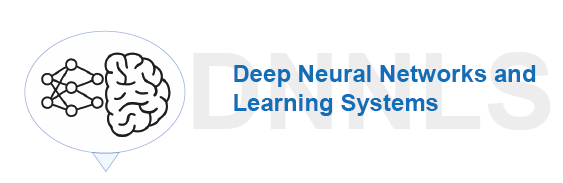

# Final assessment - Main Notebook
---

**Introduction:**

In this notebook you will find a baseline, functional architecture for your assessment task.

In [1]:
# @title Importing the necessary libraries
import torch
import torch.nn as nn
import torch.nn.functional as F

from bs4 import BeautifulSoup
import re
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
import os

from datasets import load_dataset

from datasets.fingerprint import random
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torchvision.transforms.functional as FT

from transformers import BertTokenizer
import gc

import textwrap


# **Chapter 1: The data preparation**


---



First we need to activate our google drive so that we can save out data permanently.

## 1.1 Loading and saving data

In [2]:
# @title Setting up google drive to save checkpoints

# This will prompt you to authorize Google Drive access
drive.mount('/content/gdrive')

def save_checkpoint_to_drive(model, optimizer, epoch, loss, filename="autoencoder_checkpoint.pth"):
    """
    Saves the checkpoint directly to a specified folder in your mounted Google Drive.
    """
    # 1. Define the full Google Drive path
    # 'DL_Checkpoints' is the folder you want to save to inside your Drive
    drive_folder = '/content/gdrive/MyDrive/DL_Checkpoints'

    # Ensure the directory exists before attempting to save
    os.makedirs(drive_folder, exist_ok=True)

    # 2. Combine the folder and the filename
    full_path = os.path.join(drive_folder, filename)

    # 3. Create the checkpoint dictionary
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }

    # 4. Save the dictionary to the Google Drive path
    torch.save(checkpoint, full_path)
    print(f"Checkpoint saved to Google Drive: {full_path} at epoch {epoch}")


def load_checkpoint_from_drive(model, optimizer=None, filename="autoencoder_checkpoint.pth"):
    """
    Loads a checkpoint from your Google Drive folder into the model and optimizer (if provided).
    """
    # Define the same Google Drive folder path
    drive_folder = '/content/gdrive/MyDrive/DL_Checkpoints'
    full_path = os.path.join(drive_folder, filename)

    # Check if the checkpoint file exists
    if not os.path.exists(full_path):
        raise FileNotFoundError(f"Checkpoint file not found: {full_path}")

    # Load the checkpoint
    checkpoint = torch.load(full_path, map_location=torch.device('cpu'))  # use cuda if available

    # Restore model state
    model.load_state_dict(checkpoint['model_state_dict'])

    # Restore optimizer state (if provided)
    if optimizer is not None:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    # Extract metadata
    epoch = checkpoint.get('epoch', 0)
    loss = checkpoint.get('loss', None)

    print(f"Checkpoint loaded from: {full_path} (epoch {epoch})")

    return model, optimizer, epoch, loss


Mounted at /content/gdrive


We need to define a couple of functions to make our life easier. Feel free to tweak those functions:

In [3]:
# @title Functions to load images and process data


# This function just extracts the tags from the text, don't get distracted by it.
# I changed this function a bit to fix some bugs
def parse_gdi_text(text):
    """Parse GDI formatted text into structured data"""
    soup = BeautifulSoup(text, 'html.parser')
    images = []

    for gdi in soup.find_all('gdi'):
        # Debug: print what BeautifulSoup sees

        # Method 1: Try to get image attribute directly
        image_id = None
        if gdi.attrs:
            # Check for attributes like 'image1', 'image2', etc.
            for attr_name, attr_value in gdi.attrs.items():
                if 'image' in attr_name.lower():
                    image_id = attr_name.replace('image', '')
                    break

        # Method 2: Extract from the tag string using regex
        if not image_id:
            tag_str = str(gdi)
            match = re.search(r'<gdi\s+image(\d+)', tag_str)
            if match:
                image_id = match.group(1)

        # Method 3: Fallback - use sequential numbering
        if not image_id:
            image_id = str(len(images) + 1)

        content = gdi.get_text().strip()

        # Extract tagged elements using BeautifulSoup directly
        objects = [obj.get_text().strip() for obj in gdi.find_all('gdo')]
        actions = [act.get_text().strip() for act in gdi.find_all('gda')]
        locations = [loc.get_text().strip() for loc in gdi.find_all('gdl')]

        images.append({
            'image_id': image_id,
            'description': content,
            'objects': objects,
            'actions': actions,
            'locations': locations,
            'raw_text': str(gdi)
        })

    return images

# This is an utility function to show images.
# Why do we need to do all this?
def show_image(ax, image, de_normalize = False, img_mean = None, img_std = None):
  """
  De-normalize the image (if necessary) and show image
  """
  if de_normalize:
    new_mean = -img_mean/img_std
    new_std = 1/img_std

    image = transforms.Normalize(
        mean=new_mean,
        std=new_std
    )(image)
  ax.imshow(image.permute(1, 2, 0))



Now we load dataset from HuggingFace:

In [4]:
# @title Loading the dataset
train_dataset = load_dataset("daniel3303/StoryReasoning", split="train")
test_dataset = load_dataset("daniel3303/StoryReasoning", split="test")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/327M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/331M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/115M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3552 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/626 [00:00<?, ? examples/s]

In a previous lab, we analyzed the statistics of the images and figure out that a size of 240x500 could be good enough to standarize, but we will use 60x125. Also, we will restrict ourselves to taking only 5 frames from all the sequences.


## 1.2 Three datasets


---



We will create three different dataset objects and the corresponding loaders for performing multiple tasks

In [5]:
# @title Main dataset
class SequencePredictionDataset(Dataset):
    def __init__(self, original_dataset, tokenizer):
        super(SequencePredictionDataset, self).__init__()
        self.dataset = original_dataset
        self.tokenizer = tokenizer
        # Potential experiments: Try other transforms!
        self.transform = transforms.Compose([
          transforms.Resize((60, 125)),# Reasonable size based on our previous analysis
          transforms.ToTensor(), # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      """
      Selects a 5 frame sequence from the dataset. Sets 4 for training and the last one
      as a target.
      """
      num_frames = self.dataset[idx]["frame_count"]
      frames = self.dataset[idx]["images"]
      self.image_attributes = parse_gdi_text(self.dataset[idx]["story"])

      frame_tensors = []
      description_list = []

      for frame_idx in range(4):
        image = FT.equalize(frames[frame_idx])
        input_frame = self.transform(image)
        frame_tensors.append(input_frame)

        # Potential experiments: Try using the other attributes in your training
        # objects = self.image_attributes[frame_idx]["objects"]
        # actions = self.image_attributes[frame_idx]["actions"]
        # locations = self.image_attributes[frame_idx]["locations"]

        description = self.image_attributes[frame_idx]["description"]
        # We need to return the tokens for NLP
        input_ids =  self.tokenizer(description,
                             return_tensors="pt",
                             padding="max_length",
                             truncation=True,
                             max_length=120).input_ids

        description_list.append(input_ids.squeeze(0))


      image_target = FT.equalize(frames[4])
      image_target = self.transform(image_target)
      text_target = self.image_attributes[4]["description"]

      target_ids = tokenizer(description,
                             return_tensors="pt",
                             padding="max_length",
                             truncation=True,
                             max_length=120).input_ids

      sequence_tensor = torch.stack(frame_tensors)  # shape: (num_frames, C, H, W)
      description_tensor = torch.stack(description_list) # (num_frames, max_length)

      return (sequence_tensor, # Returning the image
              description_tensor, # Returning the whole description
              image_target, # Image target
              target_ids) # Text target



We will use text autoencoding (reconstructing the same text) to develop representations of the text (I provide some existing weights for this, but you can train your own)

In [6]:
# @title Text task dataset (text autoencoding)
class TextTaskDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      num_frames = self.dataset[idx]["frame_count"]
      self.image_attributes = parse_gdi_text(self.dataset[idx]["story"])

      # Pick
      frame_idx = np.random.randint(0, 5)
      description = self.image_attributes[frame_idx]["description"]

      return description  # Returning the whole description


And also a dataset for a potential image autoencoder task if you want to develop some visual features before training the whose archicture.

In [7]:
# @title Dataset for image autoencoder task
class AutoEncoderTaskDataset(Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.transform = transforms.Compose([
          transforms.Resize((240, 500)),# Reasonable size based on our previous analysis
          transforms.ToTensor(), # HxWxC -> CxHxW
        ])

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
      num_frames = self.dataset[idx]["frame_count"]
      frames = self.dataset[idx]["images"]

      # Pick a frame at random
      frame_idx = torch.randint(0, num_frames-1, (1,)).item()
      input_frame = self.transform(frames[frame_idx]) # Input to the autoencoder

      return input_frame, # Returning the image

## 1.3 Creating and testing our dataset objects and loaders


---



In [8]:
# @title For the Sequence prediction task
tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
sp_train_dataset = SequencePredictionDataset(train_dataset, tokenizer) # Instantiate the train dataset
sp_test_dataset = SequencePredictionDataset(test_dataset, tokenizer) # Instantiate the test dataset

# Let's do things properly, we will also have a validation split
# Split the training dataset into training and validation sets
train_size = int(0.8 * len(sp_train_dataset))
val_size = len(sp_train_dataset) - train_size
train_subset, val_subset = random_split(sp_train_dataset, [train_size, val_size])

# Instantiate the dataloaders
train_dataloader = DataLoader(train_subset, batch_size=8, shuffle=True)
# We will use the validation set to visualize the progress.
val_dataloader = DataLoader(val_subset, batch_size=4, shuffle=True)
test_dataloader = DataLoader(sp_test_dataset, batch_size=4, shuffle=False)


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [9]:
# @title For the text task
tokenizer = BertTokenizer.from_pretrained("google-bert/bert-base-uncased",  padding=True, truncation=True)
text_dataset = TextTaskDataset(train_dataset)
text_dataloader = DataLoader(text_dataset, batch_size=4, shuffle=True)

In [10]:
# @title For the image autoencoder task
autoencoder_dataset = AutoEncoderTaskDataset(train_dataset)
autoencoder_dataloader = DataLoader(autoencoder_dataset, batch_size=4, shuffle=True)

Description:  torch.Size([4, 120])
torch.Size([8, 4, 3, 60, 125])
torch.Size([8, 4, 120])


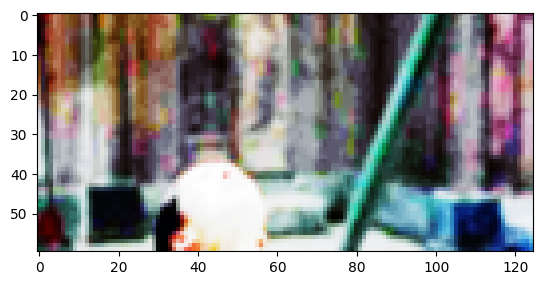

In [11]:
# @title Testing some of the outputs of the SP dataset
frames, descriptions, image_target, text_target = sp_train_dataset[np.random.randint(0,400)]

print("Description: ", descriptions.shape)
figure, ax = plt.subplots(1,1)
show_image(ax, image_target)

# Do some tests on the batches (try with batch size small)
frames, descriptions, image_target, text_target = next(iter(train_dataloader))
print(frames.shape)
print(descriptions.shape)

I will leave the test of the other datasets to you.

# **Chapter 2: Models**


---



We provide a simple text encoder based on a recurrent neural network (LSTM). Feel free to provide your own text encoder.

## 2.1 The NLP models

In [12]:
# # @title The text autoencoder (Seq2Seq)

# class EncoderLSTM(nn.Module):
#     """
#       Encodes a sequence of tokens into a latent space representation.
#     """
#     def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.1):
#         super().__init__()
#         self.vocab_size = vocab_size
#         self.embedding_dim = embedding_dim
#         self.hidden_dim = hidden_dim
#         self.num_layers = num_layers

#         self.embedding = nn.Embedding(vocab_size, embedding_dim)
#         self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
#                             batch_first=True, dropout=dropout if num_layers > 1 else 0)

#     def forward(self, input_seq):
#         embedded = self.embedding(input_seq)
#         outputs, (hidden, cell) = self.lstm(embedded)
#         return outputs, hidden, cell

# class DecoderLSTM(nn.Module):
#     """
#       Decodes a latent space representation into a sequence of tokens.
#     """
#     def __init__(self, vocab_size, embedding_dim, hidden_dim, num_layers=1, dropout=0.1):
#         super().__init__()
#         self.vocab_size = vocab_size
#         self.embedding_dim = embedding_dim
#         self.hidden_dim = hidden_dim
#         self.num_layers = num_layers

#         self.embedding = nn.Embedding(vocab_size, embedding_dim)
#         self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers,
#                             batch_first=True, dropout=dropout if num_layers > 1 else 0)
#         self.out = nn.Linear(hidden_dim, vocab_size) # Should be hidden_dim

#     def forward(self, input_seq, hidden, cell):
#         embedded = self.embedding(input_seq)
#         output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
#         prediction = self.out(output)
#         return prediction, hidden, cell

# # We create the basic text autoencoder (a special case of a sequence to sequence model)
# class Seq2SeqLSTM(nn.Module):
#     def __init__(self, encoder, decoder):
#         super().__init__()
#         self.encoder = encoder
#         self.decoder = decoder

#     def forward(self, input_seq, target_seq):
#         # input_seq and target_seq are both your 'input_ids'
#         # 1. Encode the input sequence
#         _enc_out, hidden, cell = self.encoder(input_seq)

#         # 2. Create the "shifted" decoder input for teacher forcing.
#         # We want to predict target_seq[:, 1:]
#         # So, we feed in target_seq[:, :-1]
#         # (i.e., feed "[SOS], hello, world" to predict "hello, world, [EOS]")
#         decoder_input = target_seq[:, :-1]

#         # 3. Run the decoder *once* on the entire sequence.
#         # It takes the encoder's final state (hidden, cell)
#         # and the full "teacher" sequence (decoder_input).
#         predictions, _hidden, _cell = self.decoder(decoder_input, hidden, cell)

#         # predictions shape will be (batch_size, seq_len-1, vocab_size)
#         return predictions


In [13]:
# @title Transformer-Based Text Encoder (NEW)

class TransformerTextEncoder(nn.Module):
    """
    Transformer-based text encoder - replaces LSTM encoder
    Uses self-attention to capture long-range dependencies better
    """
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim

        # Token embedding
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # Positional encoding (learnable)
        self.pos_embedding = nn.Parameter(torch.randn(1, 512, embedding_dim))

        # Transformer encoder layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embedding_dim,
            nhead=num_heads,
            dim_feedforward=hidden_dim * 2,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Project to desired hidden dimension
        self.projection = nn.Linear(embedding_dim, hidden_dim)

    def forward(self, input_seq):
        """
        Args:
            input_seq: (batch_size, seq_len)
        Returns:
            encoded: (batch_size, seq_len, hidden_dim)
            pooled: (batch_size, hidden_dim) - for compatibility
        """
        batch_size, seq_len = input_seq.shape

        # Embed tokens
        embedded = self.embedding(input_seq)  # (B, L, E)

        # Add positional encoding
        embedded = embedded + self.pos_embedding[:, :seq_len, :]

        # Apply transformer
        encoded = self.transformer(embedded)  # (B, L, E)

        # Project to hidden_dim
        encoded = self.projection(encoded)  # (B, L, H)

        # Pool for compatibility (mean pooling)
        pooled = encoded.mean(dim=1)  # (B, H)

        return encoded, pooled

In [14]:
class SharpCrossModal(nn.Module):
    def __init__(self, text_encoder, max_text_length=50):
        super().__init__()
        self.text_encoder = text_encoder
        self.max_text_length = max_text_length

        # ENCODER with separate layers for skip connections
        # Level 1: 60x125 -> 30x62
        self.enc1_1 = nn.Conv2d(3, 32, 3, padding=1)
        self.enc1_2 = nn.Conv2d(32, 32, 3, padding=1)
        self.pool1 = nn.MaxPool2d(2)

        # Level 2: 30x62 -> 15x31
        self.enc2_1 = nn.Conv2d(32, 64, 3, padding=1)
        self.enc2_2 = nn.Conv2d(64, 64, 3, padding=1)
        self.pool2 = nn.MaxPool2d(2)

        # Level 3: 15x31 (bottleneck)
        self.enc3_1 = nn.Conv2d(64, 128, 3, padding=1)
        self.enc3_2 = nn.Conv2d(128, 128, 3, padding=1)

        self.leaky = nn.LeakyReLU(0.2)

        # Text projection - now projects each token, not just pooled
        self.text_proj = nn.Linear(256, 128)

        # Cross-attention: image queries attend to text keys/values
        self.cross_attention = nn.MultiheadAttention(128, 8, batch_first=True)

        # Layer norm for stability
        self.norm1 = nn.LayerNorm(128)
        self.norm2 = nn.LayerNorm(128)

        # Feed-forward network after attention
        self.ffn = nn.Sequential(
            nn.Linear(128, 256),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128)
        )

        # DECODER with skip connections
        self.up1 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec1_1 = nn.Conv2d(128 + 64, 64, 3, padding=1)  # +64 from skip
        self.dec1_2 = nn.Conv2d(64, 64, 3, padding=1)

        self.up2 = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
        self.dec2_1 = nn.Conv2d(64 + 32, 32, 3, padding=1)   # +32 from skip
        self.dec2_2 = nn.Conv2d(32, 32, 3, padding=1)

        # Final output
        self.final = nn.Sequential(
            nn.Conv2d(32, 16, 3, padding=1),
            nn.LeakyReLU(0.2),
            nn.Conv2d(16, 3, 3, padding=1),
            nn.Tanh()
        )

        # ===== TEXT PREDICTION COMPONENTS =====
        # Simpler approach: Direct mapping from visual features to text

        # Project fused features to text space
        self.visual_to_text = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 256)
        )

        # Simple text decoder (no LSTM, just transformer-style)
        self.text_attention = nn.MultiheadAttention(256, 4, batch_first=True)
        self.text_norm = nn.LayerNorm(256)
        self.text_ffn = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(512, 256)
        )

        # Output projection to vocabulary
        self.text_output = nn.Linear(256, text_encoder.vocab_size)

    def forward(self, frames, text_inputs):
        batch_size = frames.size(0)

        # Process ALL 4 frames, not just frame 4
        all_frame_features = []
        for i in range(4):
            frame = frames[:, i, :, :, :]

            # Encode each frame
            x = self.leaky(self.enc1_1(frame))
            x = self.leaky(self.enc1_2(x))
            x = self.pool1(x)

            x = self.leaky(self.enc2_1(x))
            x = self.leaky(self.enc2_2(x))
            x = self.pool2(x)

            x = self.leaky(self.enc3_1(x))
            x = self.leaky(self.enc3_2(x))

            all_frame_features.append(x)

        # Concatenate or average all frames
        img_features = torch.stack(all_frame_features, dim=1).mean(dim=1)  # [batch, 128, 15, 31]

        # For skip connections, use the last frame
        frame4 = frames[:, -1, :, :, :]
        x = self.leaky(self.enc1_1(frame4))
        skip1 = self.leaky(self.enc1_2(x))
        x = self.pool1(skip1)

        x = self.leaky(self.enc2_1(x))
        skip2 = self.leaky(self.enc2_2(x))
        x = self.pool2(skip2)

        # Encode ALL text descriptions, not just text 4
        all_text_features = []
        for i in range(4):
            text = text_inputs[:, i, :]
            text_encoded, _ = self.text_encoder(text)
            text_proj = self.text_proj(text_encoded)
            all_text_features.append(text_proj)

        # Concatenate all text along sequence dimension
        text_tokens = torch.cat(all_text_features, dim=1)  # [batch, seq_len*4, 128]

        # Flatten spatial features
        spatial_tokens = img_features.flatten(2).permute(0, 2, 1)

        # Cross-attention
        attended, attn_weights = self.cross_attention(
            query=spatial_tokens,
            key=text_tokens,
            value=text_tokens
        )

        # Residual + norm + FFN
        spatial_tokens = self.norm1(spatial_tokens + attended)
        ffn_out = self.ffn(spatial_tokens)
        fused_features = self.norm2(spatial_tokens + ffn_out)  # [batch, 465, 128]

        # ===== IMAGE PREDICTION =====
        # Reshape back
        x = fused_features.permute(0, 2, 1).view(batch_size, 128, 15, 31)

        # DECODER with skip connections
        # Level 1: 15x31 -> 30x62
        x = self.up1(x)
        x = torch.cat([x, skip2], dim=1)
        x = self.leaky(self.dec1_1(x))
        x = self.leaky(self.dec1_2(x))

        # Level 2: 30x62 -> 60x124 (then pad/interpolate to match skip1)
        x = self.up2(x)
        if x.shape[-2:] != skip1.shape[-2:]:
            x = F.interpolate(x, size=skip1.shape[-2:], mode='bilinear', align_corners=False)
        x = torch.cat([x, skip1], dim=1)
        x = self.leaky(self.dec2_1(x))
        x = self.leaky(self.dec2_2(x))

        # Final output
        predicted_image = self.final(x)

        # Ensure exact size
        if predicted_image.shape[-2:] != (60, 125):
            predicted_image = F.interpolate(predicted_image, size=(60, 125), mode='bilinear', align_corners=False)

        # ===== TEXT PREDICTION =====
        # SIMPLEST APPROACH: Almost direct copy of frame 4 text
        # Just learn a small residual modification

        # Get frame 4's original text tokens (not features)
        frame4_text_tokens = text_inputs[:, -1, :]  # [batch, seq_len]

        # Encode it again
        frame4_encoded, _ = self.text_encoder(frame4_text_tokens)  # [batch, seq_len, 256]

        # Project to output dimension
        frame4_projected = self.visual_to_text(self.text_proj(frame4_encoded))  # [batch, seq_len, 256]

        # Add a TINY visual context as a residual
        visual_context = fused_features.mean(dim=1, keepdim=True)  # [batch, 1, 128]
        visual_residual = self.visual_to_text(visual_context)  # [batch, 1, 256]

        # Add small residual (scaled down)
        text_features = frame4_projected + 0.1 * visual_residual

        # Pad or truncate to max_text_length
        if text_features.size(1) < self.max_text_length:
            padding = torch.zeros(batch_size, self.max_text_length - text_features.size(1), 256,
                                device=text_features.device)
            text_features = torch.cat([text_features, padding], dim=1)
        else:
            text_features = text_features[:, :self.max_text_length, :]

        # Project to vocabulary - this should almost reconstruct frame 4's text
        text_logits = self.text_output(text_features)  # [batch, max_len, vocab_size]

        return predicted_image, text_logits

In [15]:
# @title Utility functions for NLP tasks
def generate(model, hidden, cell, max_len, sos_token_id, eos_token_id):
      """
        This function generates a sequence of tokens using the provided decoder.
      """
      # Ensure the model is in evaluation mode
      model.eval()

      # 2. SETUP DECODER INPUT
      # Start with the SOS token, shape (1, 1)
      dec_input = torch.tensor([[sos_token_id]], dtype=torch.long, device=device)
      # hidden = torch.zeros(1, 1, hidden_dim, device=device)
      # cell = torch.zeros(1, 1, hidden_dim, device=device)

      generated_tokens = []

      # 3. AUTOREGRESSIVE LOOP
      for _ in range(max_len):
          with torch.no_grad():
              # Run the decoder one step at a time
              # dec_input is (1, 1) here—it's just the last predicted token
              prediction, hidden, cell = model(dec_input, hidden, cell)

          logits = prediction.squeeze(1) # Shape (1, vocab_size)
          temperature = 0.9 # <--- Try a value between 0.5 and 1.0

          # 1. Divide logits by temperature
          # 2. Apply softmax to get probabilities
          # 3. Use multinomial to sample one token based on the probabilities
          probabilities = torch.softmax(logits / temperature, dim=-1)
          next_token = torch.multinomial(probabilities, num_samples=1)

          token_id = next_token.squeeze().item()

          # Check for the End-of-Sequence token
          if token_id == eos_token_id:
              break

          if token_id == 0 or token_id == sos_token_id:
              continue

            # Append the predicted token
          generated_tokens.append(token_id)

          # The predicted token becomes the input for the next iteration
          dec_input = next_token

      # Return the list of generated token IDs
      return generated_tokens


In [16]:
# @title Do some tests
# desc = text_dataset[np.random.randint(0, 100)]
# print(f"Input: {desc}")
# input_ids = tokenizer(desc, return_tensors="pt",  padding=True, truncation=True).input_ids
# input_ids = input_ids.to(device)
# generated_tokens = generate(model, hidden, cell, max_len=100, sos_token_id=tokenizer.cls_token_id, eos_token_id=tokenizer.sep_token_id)
# print("Output: ", tokenizer.decode(generated_tokens))

## 2.2 The Vision models

In [17]:
# # @title The visual autoencoder
# class Backbone(nn.Module):
#     """
#       Main convolutional blocks for our CNN
#     """
#     def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
#         super(Backbone, self).__init__()
#         # Encoder convolutional layers
#         self.encoder_conv = nn.Sequential(
#             nn.Conv2d(3, 16, 7, stride=2, padding=3),
#             nn.GroupNorm(8, 16),
#             nn.LeakyReLU(0.1),

#             nn.Conv2d(16, 32, 5, stride=2, padding=2),
#             nn.GroupNorm(8, 32),
#             nn.LeakyReLU(0.1),

#             nn.Conv2d(32, 64, 3, stride=2, padding=1),
#             nn.GroupNorm(8, 64),
#             nn.LeakyReLU(0.1),
#         )

#         # Calculate flattened dimension for linear layer
#         self.flatten_dim = 64 * output_w * output_h
#         # Latent space layers
#         self.fc1 = nn.Sequential(nn.Linear(self.flatten_dim, latent_dim), nn.ReLU())


#     def forward(self, x):
#         x = self.encoder_conv(x)
#         x = x.view(-1, self.flatten_dim)  # flatten for linear layer
#         z = self.fc1(x)
#         return z

# class VisualEncoder(nn.Module):
#     """
#       Encodes an image into a latent space representation. Note the two pathways
#       to try to disentangle the mean pattern from the image
#     """
#     def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
#         super(VisualEncoder, self).__init__()

#         self.context_backbone = Backbone(latent_dim, output_w, output_h)
#         self.content_backbone = Backbone(latent_dim, output_w, output_h)

#         self.projection = nn.Linear(2*latent_dim, latent_dim)
#     def forward(self, x):
#         z_context = self.context_backbone(x)
#         z_content = self.content_backbone(x)
#         z = torch.cat((z_content, z_context), dim=1)
#         z = self.projection(z)
#         return z

# class VisualDecoder(nn.Module):
#     """
#       Decodes a latent representation into a content image and a context image
#     """
#     def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
#         super(VisualDecoder, self).__init__()
#         self.imh = 60
#         self.imw = 125
#         self.flatten_dim = 64 * output_w * output_h
#         self.output_w = output_w
#         self.output_h = output_h

#         self.fc1 = nn.Linear(latent_dim, self.flatten_dim)

#         self.decoder_conv = nn.Sequential(
#           nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=(1,1)),
#           nn.GroupNorm(8, 32),
#           nn.LeakyReLU(0.1),

#           nn.ConvTranspose2d(32, 16, kernel_size=5, stride=2, padding=2, output_padding=1),
#           nn.GroupNorm(8, 16),
#           nn.LeakyReLU(0.1),

#           nn.ConvTranspose2d(16, 3, kernel_size=7, stride=2, padding=3, output_padding=(1, 1)),
#           nn.Sigmoid() # Use nn.Tanh() if your data is normalized to [-1, 1]
#       )

#     def forward(self, z):
#       x = self.fc1(z)

#       x_content = self.decode_image(x)
#       x_context = self.decode_image(x)

#       return x_content, x_context

#     def decode_image(self, x):
#       x = x.view(-1, 64, self.output_w, self.output_h)      # reshape to conv feature map
#       x = self.decoder_conv(x)
#       x = x[:, :, :self.imh, :self.imw]          # crop to original size if needed
#       return x

# class VisualAutoencoder( nn.Module):
#     def __init__(self, latent_dim=16, output_w = 8, output_h = 16):
#         super(VisualAutoencoder, self).__init__()
#         self.encoder = VisualEncoder(latent_dim, output_w, output_h)
#         self.decoder = VisualDecoder(latent_dim, output_w, output_h)

#     def forward(self, x):
#         z = self.encoder(x)
#         x_hat = self.decoder(z)
#         return x_hat



## 2.3 The main architecture


In [18]:
# # @title A simple attention architecture

# class Attention(nn.Module):
#     def __init__(self, hidden_dim):
#         super(Attention, self).__init__()
#         # This "attention" layer learns a query vector
#         self.attn = nn.Linear(hidden_dim, 1)
#         self.softmax = nn.Softmax(dim=1) # Over the sequence length

#     def forward(self, rnn_outputs):
#         # rnn_outputs shape: [batch, seq_len, hidden_dim]

#         # Pass through linear layer to get "energy" scores
#         energy = self.attn(rnn_outputs).squeeze(2) # Shape: [batch, seq_len]

#         # Get attention weights
#         attn_weights = self.softmax(energy) # Shape: [batch, seq_len]

#         # Apply weights
#         # attn_weights.unsqueeze(1) -> [batch, 1, seq_len]
#         # bmm with rnn_outputs -> [batch, 1, hidden_dim]
#         context = torch.bmm(attn_weights.unsqueeze(1), rnn_outputs)

#         # Squeeze to get final context vector
#         return context.squeeze(1) # Shape: [batch, hidden_dim]

In [19]:
# # @title The main sequence predictor model

# class SequencePredictor(nn.Module):
#     def __init__(self, visual_autoencoder, text_autoencoder, latent_dim,
#                  gru_hidden_dim):
#         super(SequencePredictor, self).__init__()

#         # --- 1. Static Encoders ---
#         # (These process one pair at a time)
#         self.image_encoder = visual_autoencoder.encoder
#         self.text_encoder = text_autoencoder.encoder

#         # --- 2. Temporal Encoder ---
#         # (This processes the sequence of pairs)
#         fusion_dim = latent_dim * 2 # z_visual + z_text
#         self.temporal_rnn = nn.GRU(fusion_dim, latent_dim, batch_first=True)

#         # --- 3. Attention ---
#         self.attention = Attention(gru_hidden_dim)

#         # --- 4. Final Projection ---
#         # cat(h, context) -> gru_hidden_dim * 2
#         self.projection = nn.Sequential(
#             nn.Linear(gru_hidden_dim * 2, latent_dim),
#             nn.ReLU()
#         )

#         # --- 5. Decoders ---
#         # (These predict the *next* item)
#         self.image_decoder = visual_autoencoder.decoder
#         self.text_decoder = text_autoencoder.decoder

#         self.fused_to_h0 = nn.Linear(latent_dim, 16)
#         self.fused_to_c0 = nn.Linear(latent_dim, 16)

#     def forward(self, image_seq, text_seq, target_seq):
#         # image_seq shape: [batch, seq_len, C, H, W]
#         # text_seq shape:  [batch, seq_len, text_len]
#         # target_text_for_teacher_forcing: [batch, text_len] (This is the last text)

#         batch_size, seq_len, C, H, W = image_seq.shape

#         # --- 1 & 2: Run Static Encoders over the sequence ---
#         # We can't pass a 5D/4D tensor to the encoders.
#         # We "flatten" the batch and sequence dimensions.

#         # Reshape for image_encoder
#         img_flat = image_seq.view(batch_size * seq_len, C, H, W)
#         # Reshape for text_encoder
#         txt_flat = text_seq.view(batch_size * seq_len, -1) # -1 infers text_len

#         # Run encoders
#         z_v_flat = self.image_encoder(img_flat) # Shape: [b*s, latent]
#         _, hidden, cell = self.text_encoder(txt_flat) # Shape: [b*s, latent]

#         # Combine
#         z_fusion_flat = torch.cat((z_v_flat, hidden.squeeze(0)), dim=1) # Shape: [b*s, fusion_dim]

#         # "Un-flatten" back into a sequence
#         z_fusion_seq = z_fusion_flat.view(batch_size, seq_len, -1) # Shape: [b, s, fusion_dim]

#         # --- 3. Run Temporal Encoder ---
#         # zseq shape: [b, s, gru_hidden]
#         # h    shape: [1, b, gru_hidden]
#         zseq, h = self.temporal_rnn(z_fusion_seq)
#         h = h.squeeze(0) # Shape: [b, gru_hidden]

#         # --- 4. Attention ---
#         context = self.attention(zseq) # Shape: [b, gru_hidden]

#         # --- 5. Final Prediction Vector (z) ---
#         z = self.projection(torch.cat((h, context), dim=1)) # Shape: [b, joint_latent_dim]

#         # --- 6. Decode (Predict pk) ---
#         pred_image_content, pred_image_context = self.image_decoder(z)

#         h0 = self.fused_to_h0(z).unsqueeze(0)
#         c0 = self.fused_to_c0(z).unsqueeze(0)

#         decoder_input = target_seq[:, :,:-1].squeeze(1)

#         # 3. Run the decoder *once* on the entire sequence.
#         # It takes the encoder's final state (hidden, cell)
#         # and the full "teacher" sequence (decoder_input).
#         predicted_text_logits_k, _hidden, _cell = self.text_decoder(decoder_input, h0, c0)

#         return pred_image_content, pred_image_context, predicted_text_logits_k,h0, c0

# **Chapter 3: Training routines**


---




In [20]:
def validation(model, data_loader, tokenizer):
    """Validation function with text under each image"""
    model.eval()
    with torch.no_grad():
        frames, descriptions, image_target, text_target = next(iter(data_loader))

        frames = frames.to(device)
        descriptions = descriptions.to(device)
        image_target = image_target.to(device)
        text_target = text_target.to(device)

        # Get predictions - NOW RETURNS BOTH
        predicted_image, predicted_text_logits = model(frames, descriptions)

        if predicted_image.shape[-2:] != (60, 125):
            predicted_image = F.interpolate(predicted_image, size=(60, 125),
                                           mode='bilinear', align_corners=False)

        # Decode predicted text
        predicted_text_ids = predicted_text_logits[0].argmax(dim=-1)
        predicted_text = tokenizer.decode(predicted_text_ids, skip_special_tokens=True)

        figure, ax = plt.subplots(2, 6, figsize=(20, 8),
                                 gridspec_kw={'height_ratios': [3, 1]})

        # Show input frames 1-4 with their text
        for i in range(4):
            img = frames[0, i, :, :, :].cpu()
            show_image(ax[0, i], img)
            ax[0, i].set_title(f'Frame {i+1}', fontsize=11)
            ax[0, i].axis('off')

            wrapped_text = textwrap.fill(
                tokenizer.decode(descriptions[0, i, :], skip_special_tokens=True),
                width=30
            )
            ax[1, i].text(0.5, 0.5, wrapped_text, ha='center', va='center', fontsize=9)
            ax[1, i].axis('off')

        # Ground truth frame 5
        show_image(ax[0, 4], image_target[0].cpu())
        ax[0, 4].set_title('Expected(Target)Frame 5', fontsize=11, color='green')
        ax[0, 4].axis('off')

        gt_text = tokenizer.decode(text_target[0].squeeze(), skip_special_tokens=True)
        wrapped_text = textwrap.fill(gt_text, width=30)
        ax[1, 4].text(0.5, 0.5, wrapped_text, ha='center', va='center', fontsize=9)
        ax[1, 4].axis('off')

        # Predicted frame 5
        show_image(ax[0, 5], predicted_image[0].cpu())
        ax[0, 5].set_title('Predicted Frame 5', fontsize=11, color='blue')
        ax[0, 5].axis('off')

        # PREDICTED TEXT (not ground truth!)
        wrapped_text = textwrap.fill(
            f"Predicted: {predicted_text}",
            width=30
        )
        ax[1, 5].text(0.5, 0.5, wrapped_text, ha='center', va='center',
                     fontsize=9, color='blue')
        ax[1, 5].axis('off')

        plt.suptitle('Frame Predictions with Text Descriptions', fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()

    model.train()

In [21]:
# # @title Training utility functions: To initialize and to visualize the progress


# def init_weights(m):
#     if isinstance(m, nn.Conv2d) or isinstance(m, nn.ConvTranspose2d):
#         nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
#         if m.bias is not None:
#             nn.init.zeros_(m.bias)
#     elif isinstance(m, nn.Linear):
#         nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='leaky_relu')
#         nn.init.constant_(m.bias, 0)


# # Plots four images and their reconstructions
# def validation( model, data_loader ):
#   model.eval()
#   with torch.no_grad():
#     frames, descriptions, image_target, text_target = next(iter(data_loader))

#     descriptions = descriptions.to(device)
#     frames = frames.to(device)
#     image_target = image_target.to(device)
#     text_target = text_target.to(device)

#     predicted_image_k,context_image, _, hidden, cell = model(frames, descriptions, text_target)

#     figure, ax = plt.subplots(2, 6, figsize=(20, 5), gridspec_kw={'height_ratios': [2, 1.5]})

#     for i in range(4):
#       im = frames[0, i, :, :, :].cpu()
#       show_image(ax[0,i], im )
#       ax[0,i].set_aspect('auto')
#       ax[0,i].axis('off')
#       wrapped_text = textwrap.fill(tokenizer.decode(descriptions[0, i, :], skip_special_tokens=True), width=40)

#       ax[1,i].text(
#             0.5, 0.99,
#             wrapped_text,
#             ha='center',
#             va='top',
#             fontsize=10,
#             wrap=True
#         )

#       ax[1,i].axis('off') # Hide axes for the text subplot

#     show_image(ax[0,4], image_target[0].cpu())
#     ax[0,4].set_title('Target')
#     ax[0,4].set_aspect('auto')
#     ax[0,4].axis('off')
#     text_target = text_target.squeeze(1)

#     wrapped_text = textwrap.fill(tokenizer.decode(text_target[0], skip_special_tokens=True), width=40)
#     ax[1,4].text(
#             0.5, 0.99,
#             wrapped_text,
#             ha='center',
#             va='top',
#             fontsize=10,
#             wrap=False)
#     ax[1,4].axis('off')
#     output = context_image[0, :, :, :].cpu()
#     show_image(ax[0,5], output)
#     ax[0,5].set_title('Predicted')
#     ax[0,5].set_aspect('auto')
#     ax[0,5].axis('off')

#     generated_tokens = generate(model.text_decoder,
#                                 hidden[:,0, :].unsqueeze(1),
#                                 cell[:, 0, :].unsqueeze(1),
#                                 max_len=150,
#                                 sos_token_id=tokenizer.cls_token_id,
#                                 eos_token_id=tokenizer.sep_token_id)

#     wrapped_text = textwrap.fill(tokenizer.decode(generated_tokens), width=40)

#     ax[1,5].text(
#             0.5, 0.99,
#             wrapped_text,
#             ha='center',
#             va='top',
#             fontsize=10,
#             wrap=False )
#     ax[1,5].axis('off')
#     plt.tight_layout()
#     plt.show()


## 3.1 Initialization and setup

In [22]:
# @title Simple Setup for Cross-Modal Transformer (NEW)
torch.cuda.empty_cache()
gc.collect()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Hyperparameters
N_EPOCHS = 10  # More epochs for transformers
learning_rate = 1e-4

print(f"Using device: {device}")

Using device: cuda


In [23]:
# # @title Variables and initial setup
# torch.cuda.empty_cache()
# gc.collect()
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# N_EPOCHS = 5
# emb_dim = 16
# latent_dim = 16
# num_layers = 1
# dropout = True

In [24]:
# # @title Initializing the NLP models
# encoder = EncoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
# decoder = DecoderLSTM(tokenizer.vocab_size, emb_dim, latent_dim, num_layers, dropout).to(device)
# text_autoencoder = Seq2SeqLSTM(encoder, decoder).to(device)
# text_autoencoder, _, _, _ = load_checkpoint_from_drive(text_autoencoder, None, filename='text_autoencoder.pth')

# total_params = sum(p.numel() for p in text_autoencoder.parameters())
# print(f"Total parameters (Not trainable): {total_params}")
# # Deactivating training from this model for efficiency (although not ideal)
# for param in text_autoencoder.parameters():
#         param.requires_grad = False


In [25]:
# # @title Initializing visual models
# visual_autoencoder = VisualAutoencoder(latent_dim=16)
# visual_autoencoder.apply(init_weights)

# total_params = sum(p.numel() for p in visual_autoencoder.parameters() if p.requires_grad)
# print(f"Total trainable parameters in visual autoencoder: {total_params}")

In [26]:
# # @title Initialize the main architecture
# # We put all the sizes the same, not ideal as well
# sequence_predictor = SequencePredictor(visual_autoencoder, text_autoencoder, latent_dim, latent_dim)
# sequence_predictor.to(device)

# # # Print number of trainable parameters
# total_params = sum(p.numel() for p in sequence_predictor.parameters() if p.requires_grad)
# print(f"Total trainable parameters in the whole model: {total_params}")

# # Print model size
# total_params = sum(p.numel() for p in sequence_predictor.parameters())
# print(f"Total parameters: {total_params}")

In [27]:
# # @title Add Perceptual Loss

# import torch
# import torch.nn as nn
# import torchvision.models as models

# class LightweightPerceptualLoss(nn.Module):
#     def __init__(self):
#         super().__init__()
#         vgg = models.vgg16(pretrained=True)
#         self.features = nn.Sequential(*list(vgg.features[:9])).eval()
#         for param in self.features.parameters():
#             param.requires_grad = False
#         self.criterion = nn.MSELoss()

#     def forward(self, pred, target):
#         pred_normalized = (pred - 0.5) / 0.5
#         target_normalized = (target - 0.5) / 0.5
#         pred_features = self.features(pred_normalized)
#         target_features = self.features(target_normalized)
#         return self.criterion(pred_features, target_features)

# # Initialize it
# perceptual_loss = LightweightPerceptualLoss()

## 3.2 Training loops

Epoch 1, Batch 0, Total: 31.0435, Image: 0.4682, Text: 10.3166
Epoch 1, Batch 10, Total: 30.6150, Image: 0.4156, Text: 10.1773
Epoch 1, Batch 20, Total: 29.8163, Image: 0.2884, Text: 9.9195
Epoch 1, Batch 30, Total: 28.0047, Image: 0.2713, Text: 9.3168
Epoch 1, Batch 40, Total: 24.8380, Image: 0.2557, Text: 8.2623
Epoch 1, Batch 50, Total: 23.0409, Image: 0.2483, Text: 7.6638
Epoch 1, Batch 60, Total: 21.8239, Image: 0.2511, Text: 7.2579
Epoch 1, Batch 70, Total: 20.4647, Image: 0.2510, Text: 6.8048
Epoch 1, Batch 80, Total: 20.0513, Image: 0.2502, Text: 6.6671
Epoch 1, Batch 90, Total: 19.6173, Image: 0.2517, Text: 6.5223
Epoch 1, Batch 100, Total: 17.8063, Image: 0.2483, Text: 5.9189
Epoch 1, Batch 110, Total: 18.0868, Image: 0.2453, Text: 6.0126
Epoch 1, Batch 120, Total: 17.9228, Image: 0.2387, Text: 5.9584
Epoch 1, Batch 130, Total: 17.7464, Image: 0.2489, Text: 5.8989
Epoch 1, Batch 140, Total: 17.4391, Image: 0.2407, Text: 5.7970
Epoch 1, Batch 150, Total: 16.4549, Image: 0.2467

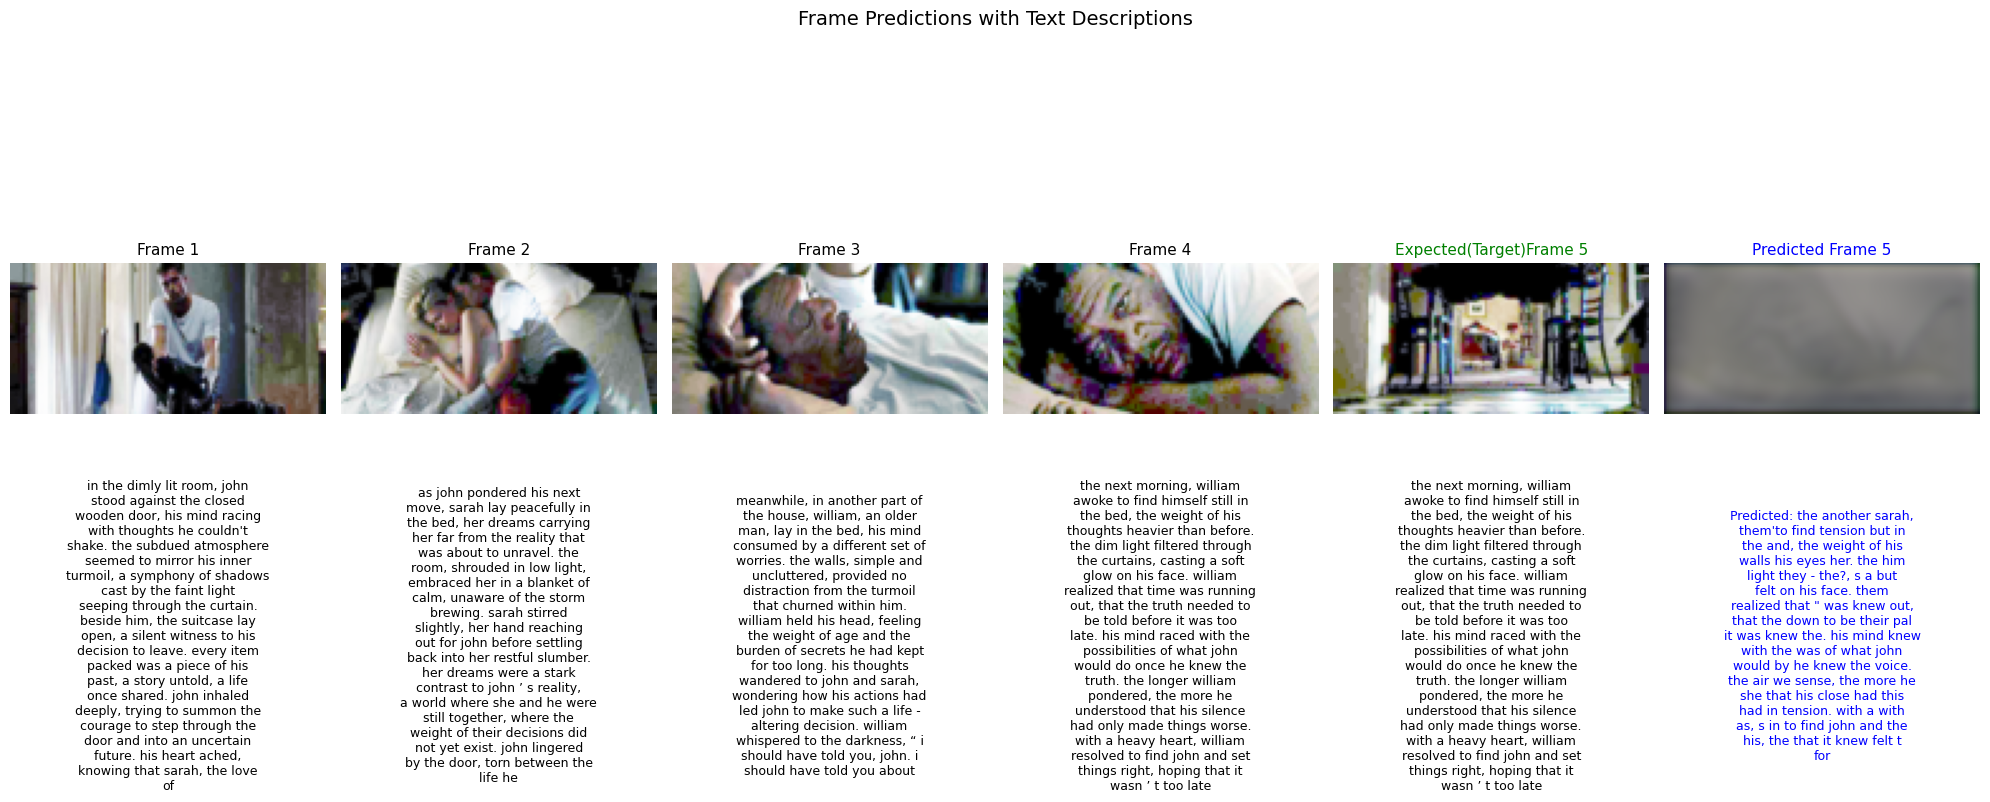

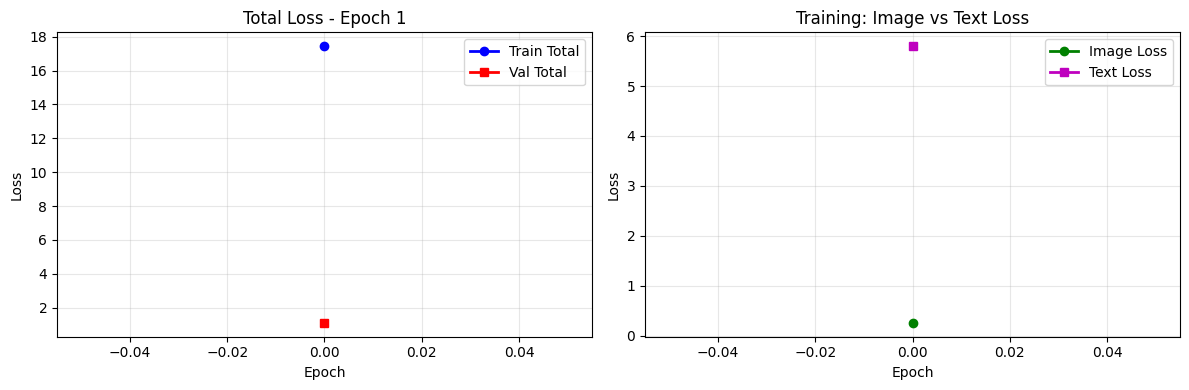

Epoch 2, Batch 0, Total: 11.9553, Image: 0.2448, Text: 3.9688
Epoch 2, Batch 10, Total: 11.1120, Image: 0.2530, Text: 3.6871
Epoch 2, Batch 20, Total: 11.3675, Image: 0.2609, Text: 3.7718
Epoch 2, Batch 30, Total: 10.9734, Image: 0.2463, Text: 3.6414
Epoch 2, Batch 40, Total: 11.1783, Image: 0.2246, Text: 3.7111
Epoch 2, Batch 50, Total: 11.0816, Image: 0.2399, Text: 3.6779
Epoch 2, Batch 60, Total: 11.2327, Image: 0.2299, Text: 3.7289
Epoch 2, Batch 70, Total: 10.6182, Image: 0.2428, Text: 3.5232
Epoch 2, Batch 80, Total: 10.7310, Image: 0.2362, Text: 3.5612
Epoch 2, Batch 90, Total: 10.0812, Image: 0.2522, Text: 3.3436
Epoch 2, Batch 100, Total: 10.6817, Image: 0.2295, Text: 3.5453
Epoch 2, Batch 110, Total: 10.7772, Image: 0.2364, Text: 3.5767
Epoch 2, Batch 120, Total: 9.6122, Image: 0.2430, Text: 3.1879
Epoch 2, Batch 130, Total: 9.6770, Image: 0.2496, Text: 3.2090
Epoch 2, Batch 140, Total: 10.1743, Image: 0.2391, Text: 3.3755
Epoch 2, Batch 150, Total: 9.9639, Image: 0.2392, Tex

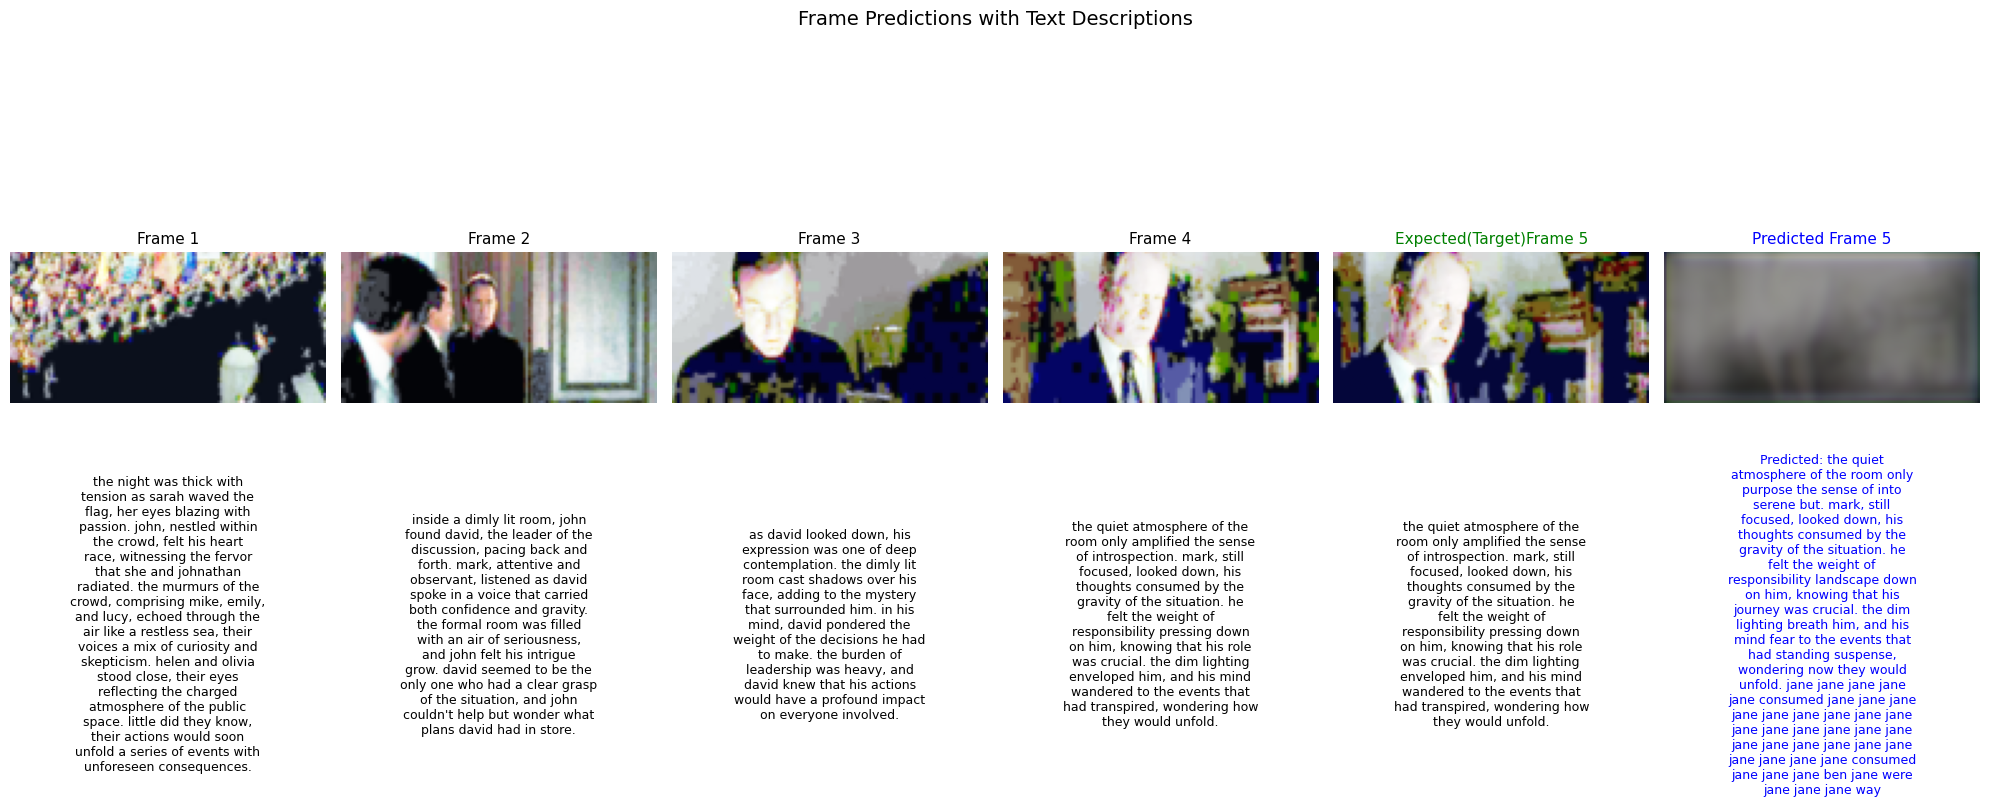

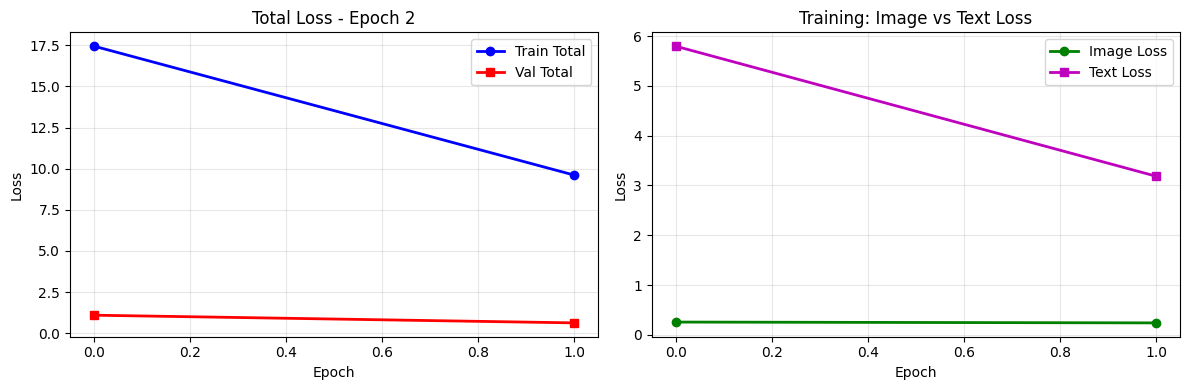

Epoch 3, Batch 0, Total: 7.8476, Image: 0.2516, Text: 2.5991
Epoch 3, Batch 10, Total: 8.0395, Image: 0.2286, Text: 2.6646
Epoch 3, Batch 20, Total: 7.7949, Image: 0.2241, Text: 2.5834
Epoch 3, Batch 30, Total: 8.4213, Image: 0.2278, Text: 2.7919
Epoch 3, Batch 40, Total: 8.1395, Image: 0.2410, Text: 2.6971
Epoch 3, Batch 50, Total: 7.7956, Image: 0.2412, Text: 2.5825
Epoch 3, Batch 60, Total: 8.5421, Image: 0.2384, Text: 2.8315
Epoch 3, Batch 70, Total: 7.5330, Image: 0.2573, Text: 2.4938
Epoch 3, Batch 80, Total: 7.4552, Image: 0.2574, Text: 2.4679
Epoch 3, Batch 90, Total: 6.9353, Image: 0.2349, Text: 2.2961
Epoch 3, Batch 100, Total: 8.1235, Image: 0.2432, Text: 2.6916
Epoch 3, Batch 110, Total: 7.5481, Image: 0.2305, Text: 2.5007
Epoch 3, Batch 120, Total: 7.2851, Image: 0.2326, Text: 2.4129
Epoch 3, Batch 130, Total: 7.6724, Image: 0.2357, Text: 2.5418
Epoch 3, Batch 140, Total: 6.8951, Image: 0.2473, Text: 2.2819
Epoch 3, Batch 150, Total: 7.9018, Image: 0.2342, Text: 2.6183
Epo

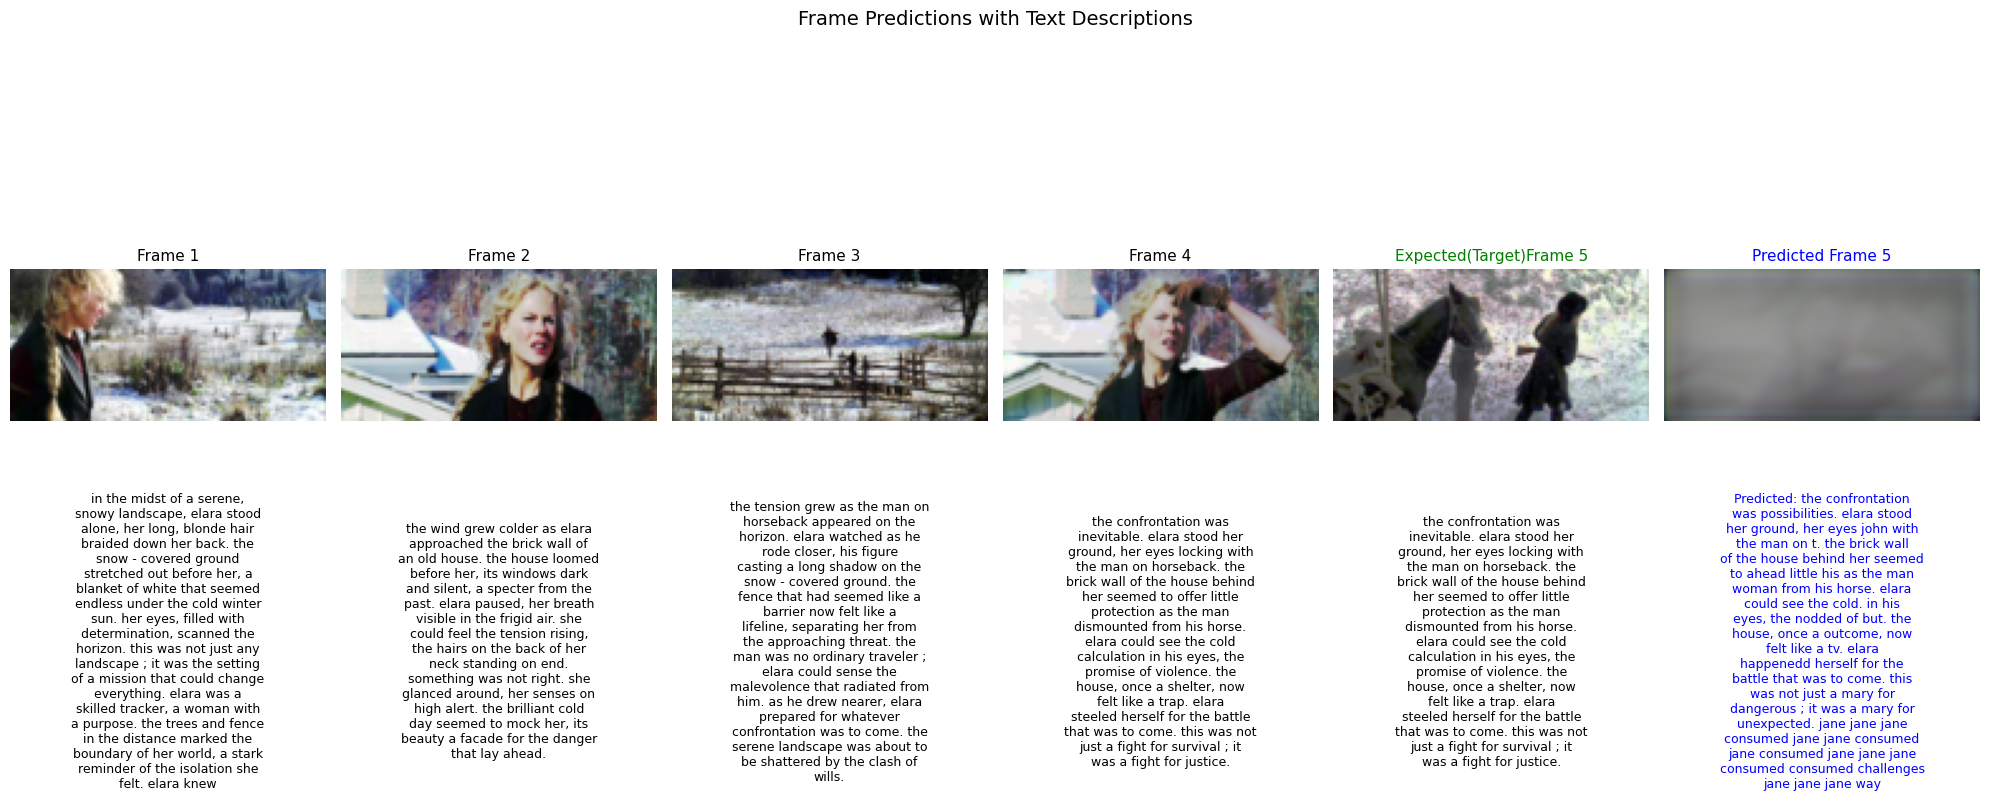

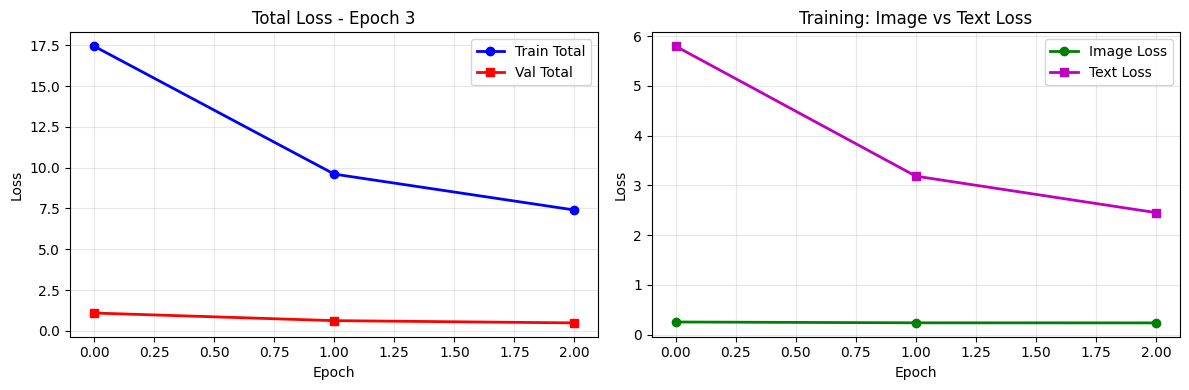

Epoch 4, Batch 0, Total: 7.1827, Image: 0.2405, Text: 2.3782
Epoch 4, Batch 10, Total: 6.5494, Image: 0.2384, Text: 2.1673
Epoch 4, Batch 20, Total: 7.0715, Image: 0.2306, Text: 2.3418
Epoch 4, Batch 30, Total: 6.2001, Image: 0.2333, Text: 2.0511
Epoch 4, Batch 40, Total: 6.7420, Image: 0.2267, Text: 2.2322
Epoch 4, Batch 50, Total: 6.5055, Image: 0.2300, Text: 2.1532
Epoch 4, Batch 60, Total: 6.2944, Image: 0.2259, Text: 2.0831
Epoch 4, Batch 70, Total: 6.7301, Image: 0.2377, Text: 2.2275
Epoch 4, Batch 80, Total: 6.3784, Image: 0.2342, Text: 2.1105
Epoch 4, Batch 90, Total: 6.4534, Image: 0.2549, Text: 2.1341
Epoch 4, Batch 100, Total: 6.4253, Image: 0.2385, Text: 2.1259
Epoch 4, Batch 110, Total: 6.5618, Image: 0.2340, Text: 2.1717
Epoch 4, Batch 120, Total: 6.4276, Image: 0.2454, Text: 2.1262
Epoch 4, Batch 130, Total: 6.6905, Image: 0.2429, Text: 2.2140
Epoch 4, Batch 140, Total: 6.5363, Image: 0.2469, Text: 2.1623
Epoch 4, Batch 150, Total: 6.9169, Image: 0.2374, Text: 2.2898
Epo

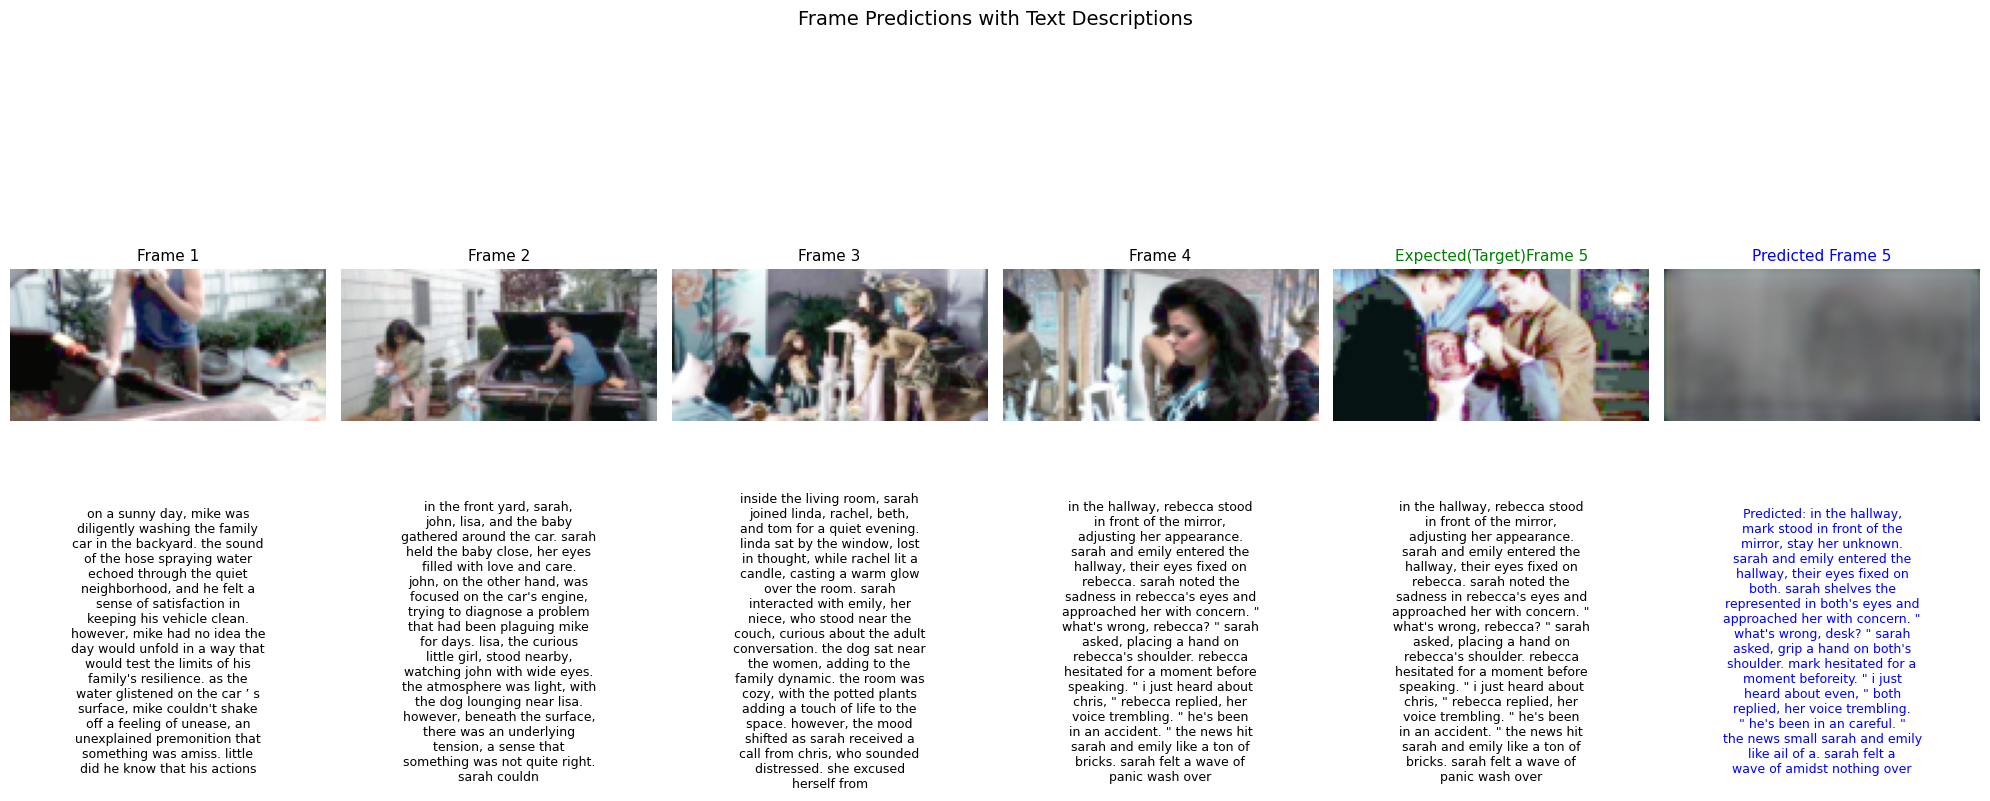

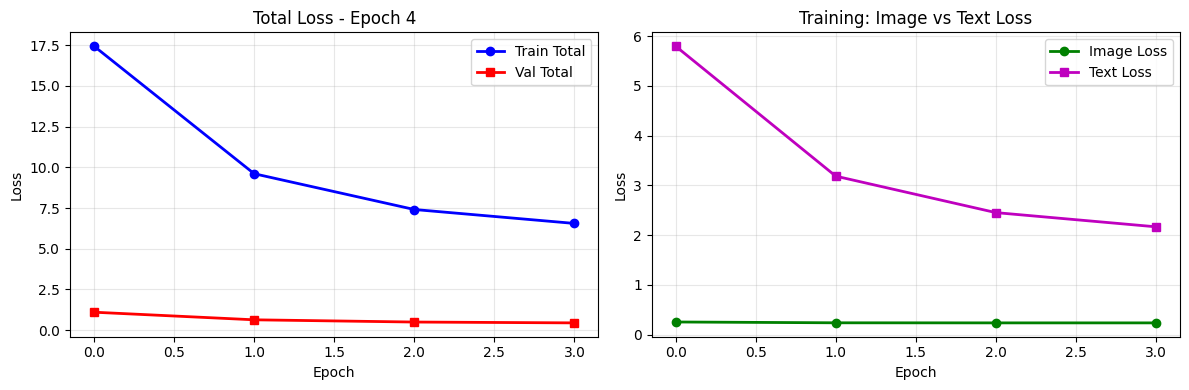

Epoch 5, Batch 0, Total: 6.3499, Image: 0.2292, Text: 2.1014
Epoch 5, Batch 10, Total: 6.0726, Image: 0.2377, Text: 2.0084
Epoch 5, Batch 20, Total: 5.7646, Image: 0.2278, Text: 1.9064
Epoch 5, Batch 30, Total: 6.5941, Image: 0.2417, Text: 2.1819
Epoch 5, Batch 40, Total: 6.0801, Image: 0.2517, Text: 2.0099
Epoch 5, Batch 50, Total: 6.1364, Image: 0.2331, Text: 2.0299
Epoch 5, Batch 60, Total: 6.2828, Image: 0.2393, Text: 2.0783
Epoch 5, Batch 70, Total: 6.2551, Image: 0.2278, Text: 2.0698
Epoch 5, Batch 80, Total: 6.3323, Image: 0.2438, Text: 2.0945
Epoch 5, Batch 90, Total: 6.5510, Image: 0.2358, Text: 2.1679
Epoch 5, Batch 100, Total: 6.1736, Image: 0.2532, Text: 2.0410
Epoch 5, Batch 110, Total: 6.3789, Image: 0.2338, Text: 2.1107
Epoch 5, Batch 120, Total: 6.1706, Image: 0.2475, Text: 2.0404
Epoch 5, Batch 130, Total: 5.7386, Image: 0.2429, Text: 1.8967
Epoch 5, Batch 140, Total: 6.2234, Image: 0.2293, Text: 2.0592
Epoch 5, Batch 150, Total: 6.3099, Image: 0.2292, Text: 2.0880
Epo

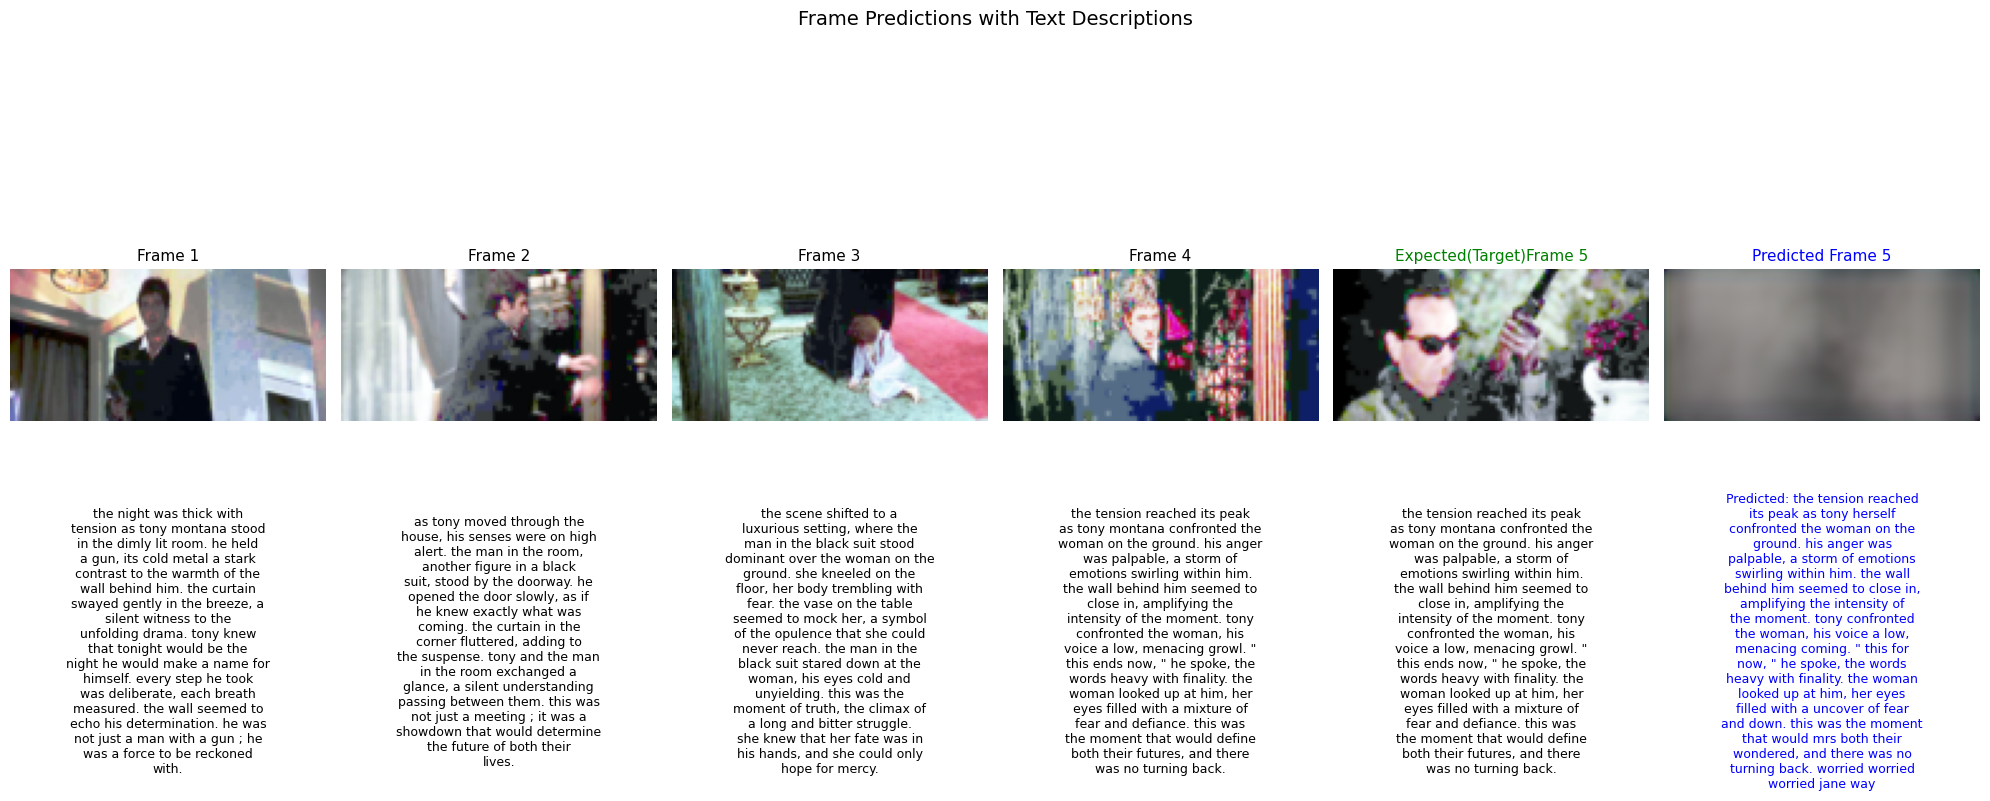

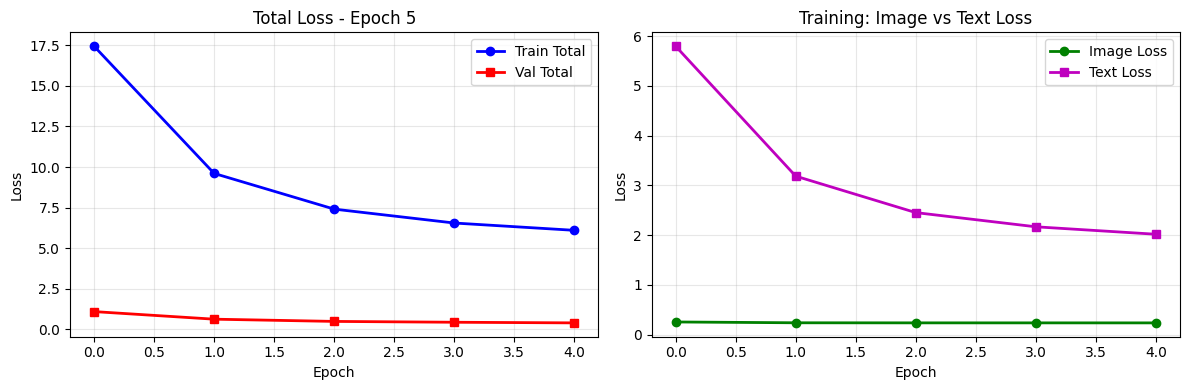

Epoch 6, Batch 0, Total: 5.9056, Image: 0.2296, Text: 1.9532
Epoch 6, Batch 10, Total: 6.0038, Image: 0.2302, Text: 1.9859
Epoch 6, Batch 20, Total: 5.6849, Image: 0.2386, Text: 1.8791
Epoch 6, Batch 30, Total: 5.9199, Image: 0.2271, Text: 1.9582
Epoch 6, Batch 40, Total: 5.8767, Image: 0.2364, Text: 1.9431
Epoch 6, Batch 50, Total: 6.3028, Image: 0.2579, Text: 2.0837
Epoch 6, Batch 60, Total: 6.2556, Image: 0.2392, Text: 2.0692
Epoch 6, Batch 70, Total: 5.9396, Image: 0.2487, Text: 1.9633
Epoch 6, Batch 80, Total: 5.7946, Image: 0.2331, Text: 1.9160
Epoch 6, Batch 90, Total: 6.0779, Image: 0.2348, Text: 2.0103
Epoch 6, Batch 100, Total: 6.2050, Image: 0.2485, Text: 2.0518
Epoch 6, Batch 110, Total: 5.7844, Image: 0.2253, Text: 1.9131
Epoch 6, Batch 120, Total: 6.1815, Image: 0.2280, Text: 2.0453
Epoch 6, Batch 130, Total: 6.0541, Image: 0.2254, Text: 2.0030
Epoch 6, Batch 140, Total: 5.5597, Image: 0.2362, Text: 1.8375
Epoch 6, Batch 150, Total: 5.5791, Image: 0.2419, Text: 1.8436
Epo

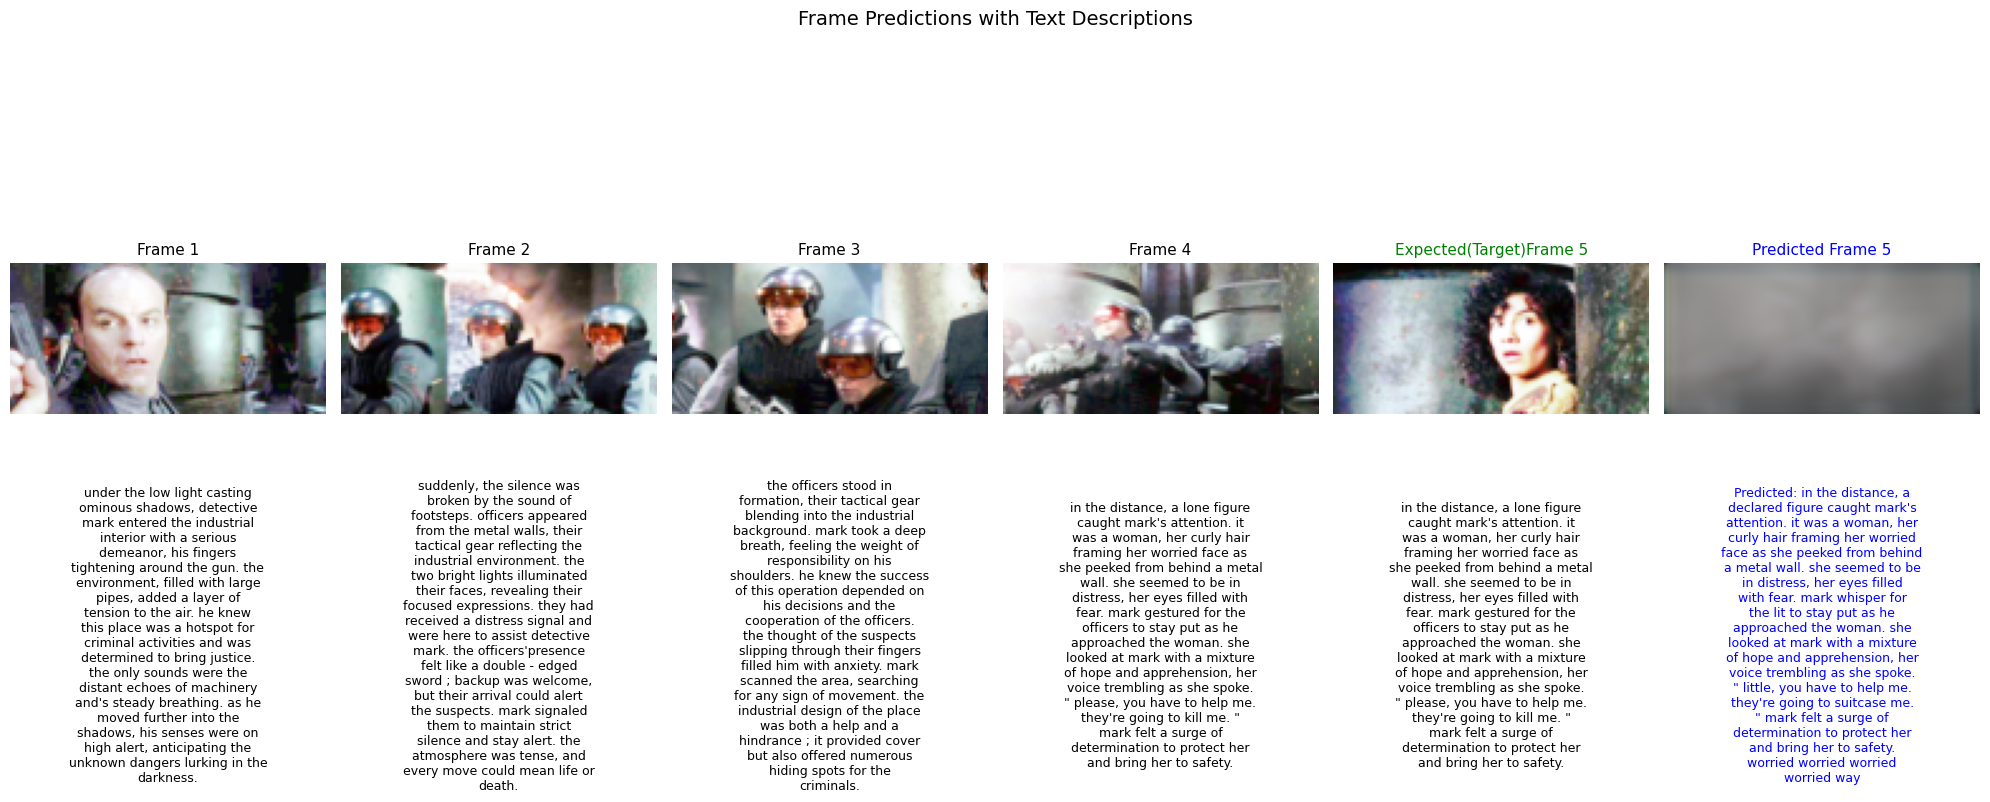

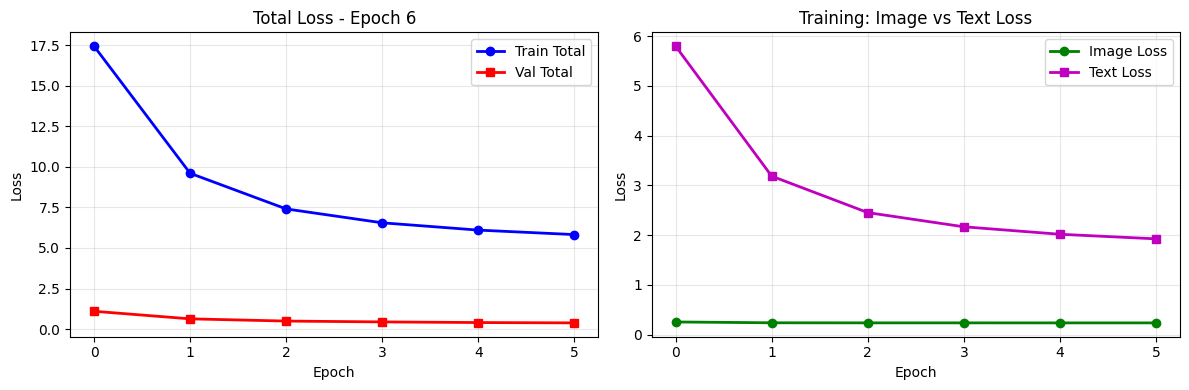

Epoch 7, Batch 0, Total: 5.9976, Image: 0.2352, Text: 1.9835
Epoch 7, Batch 10, Total: 5.5378, Image: 0.2333, Text: 1.8304
Epoch 7, Batch 20, Total: 5.9686, Image: 0.2328, Text: 1.9740
Epoch 7, Batch 30, Total: 5.5030, Image: 0.2463, Text: 1.8179
Epoch 7, Batch 40, Total: 5.5568, Image: 0.2515, Text: 1.8355
Epoch 7, Batch 50, Total: 5.4241, Image: 0.2328, Text: 1.7925
Epoch 7, Batch 60, Total: 5.6720, Image: 0.2330, Text: 1.8751
Epoch 7, Batch 70, Total: 5.3947, Image: 0.2605, Text: 1.7809
Epoch 7, Batch 80, Total: 5.4500, Image: 0.2238, Text: 1.8017
Epoch 7, Batch 90, Total: 5.6109, Image: 0.2421, Text: 1.8542
Epoch 7, Batch 100, Total: 6.0970, Image: 0.2388, Text: 2.0164
Epoch 7, Batch 110, Total: 5.8286, Image: 0.2407, Text: 1.9268
Epoch 7, Batch 120, Total: 5.6062, Image: 0.2388, Text: 1.8528
Epoch 7, Batch 130, Total: 5.3685, Image: 0.2377, Text: 1.7736
Epoch 7, Batch 140, Total: 5.3401, Image: 0.2363, Text: 1.7643
Epoch 7, Batch 150, Total: 5.6974, Image: 0.2507, Text: 1.8824
Epo

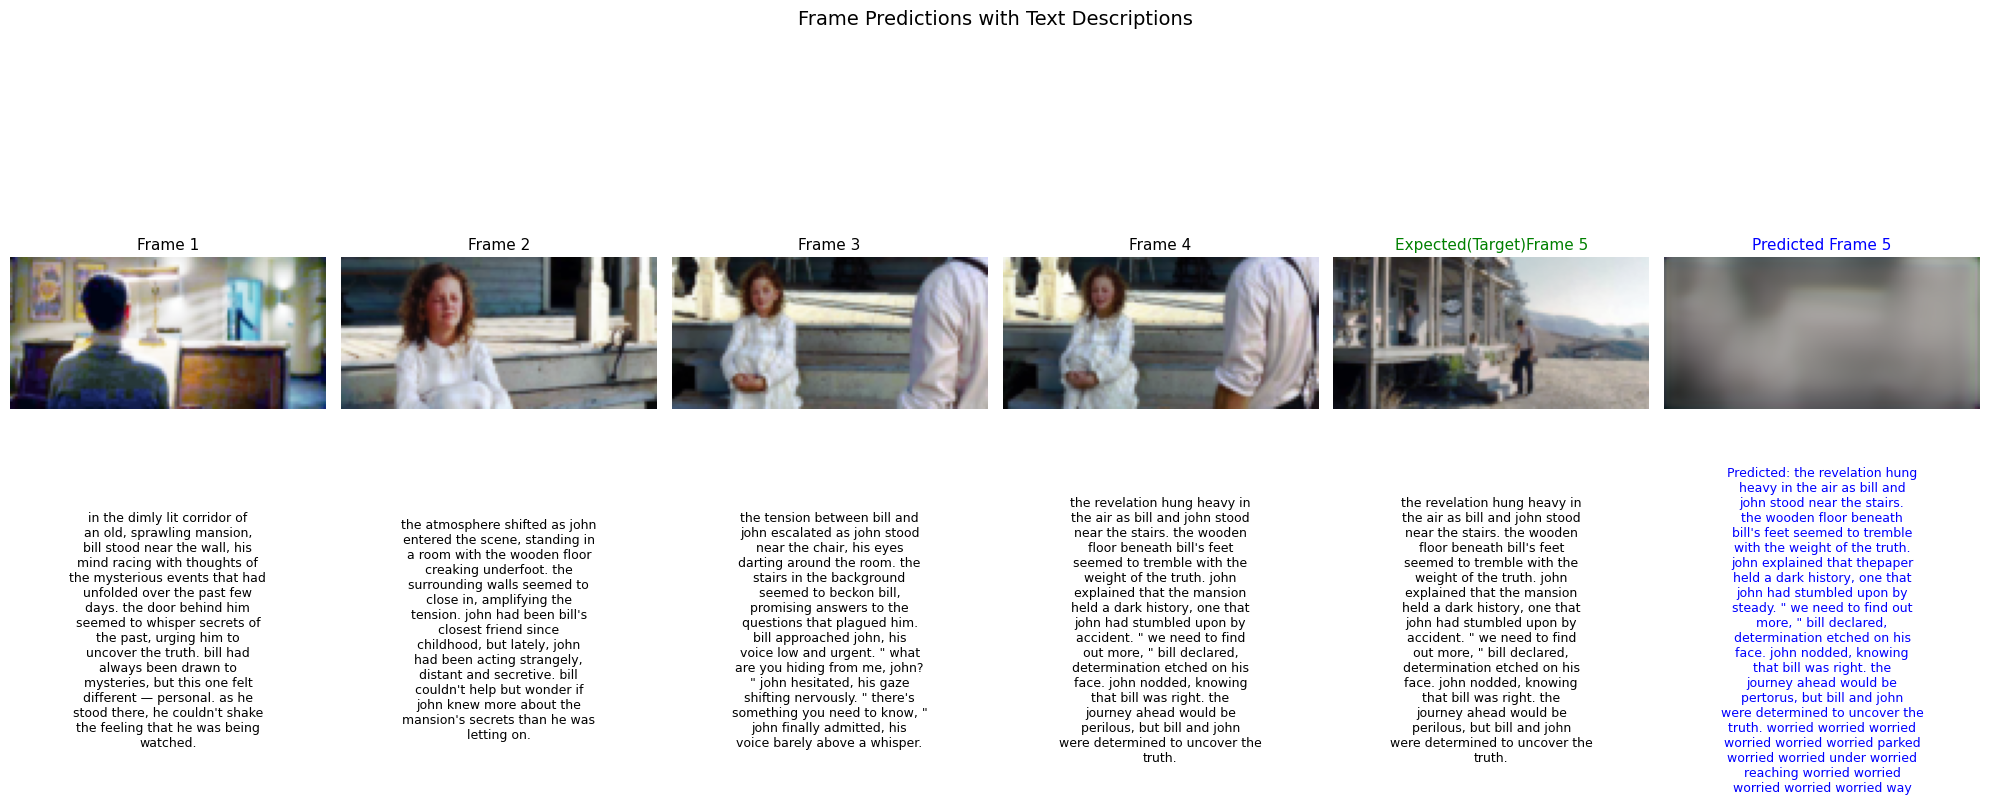

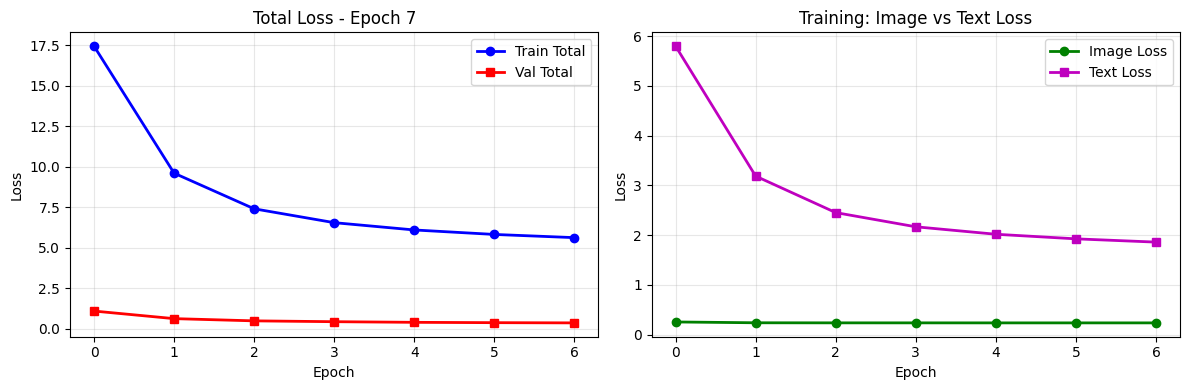

Epoch 8, Batch 0, Total: 5.3466, Image: 0.2311, Text: 1.7668
Epoch 8, Batch 10, Total: 5.4222, Image: 0.2294, Text: 1.7921
Epoch 8, Batch 20, Total: 5.3866, Image: 0.2311, Text: 1.7801
Epoch 8, Batch 30, Total: 5.4541, Image: 0.2330, Text: 1.8025
Epoch 8, Batch 40, Total: 5.4547, Image: 0.2440, Text: 1.8020
Epoch 8, Batch 50, Total: 5.4986, Image: 0.2291, Text: 1.8176
Epoch 8, Batch 60, Total: 5.5352, Image: 0.2297, Text: 1.8298
Epoch 8, Batch 70, Total: 5.5759, Image: 0.2463, Text: 1.8422
Epoch 8, Batch 80, Total: 5.4225, Image: 0.2261, Text: 1.7924
Epoch 8, Batch 90, Total: 5.1838, Image: 0.2288, Text: 1.7127
Epoch 8, Batch 100, Total: 5.2777, Image: 0.2304, Text: 1.7439
Epoch 8, Batch 110, Total: 5.5516, Image: 0.2352, Text: 1.8349
Epoch 8, Batch 120, Total: 5.5540, Image: 0.2193, Text: 1.8367
Epoch 8, Batch 130, Total: 5.4060, Image: 0.2334, Text: 1.7865
Epoch 8, Batch 140, Total: 5.1510, Image: 0.2233, Text: 1.7021
Epoch 8, Batch 150, Total: 5.5399, Image: 0.2339, Text: 1.8311
Epo

In [ ]:
# @title Training Loop with Image AND Text Loss

# Define text encoder
text_encoder = TransformerTextEncoder(
    vocab_size=tokenizer.vocab_size,
    embedding_dim=256,
    hidden_dim=256,
    num_heads=4,
    num_layers=2
)

# Use the SHARP model
# Align max_text_length with the dataset's tokenizer max_length (120)
model = SharpCrossModal(text_encoder, max_text_length=120).to(device)

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Loss functions
criterion_image = nn.L1Loss()

# Store losses for plotting
train_losses = []
val_losses = []
train_image_losses = []
train_text_losses = []

# Training
num_epochs = 10
for epoch in range(num_epochs):
    # === TRAINING ===
    model.train()
    epoch_train_loss = 0
    epoch_image_loss = 0
    epoch_text_loss = 0
    batch_count = 0

    for batch_idx, (frames, descriptions, image_target, text_target) in enumerate(train_dataloader):
        frames = frames.to(device)
        descriptions = descriptions.to(device)
        image_target = image_target.to(device)
        text_target = text_target.to(device)

        # Forward - RETURNS BOTH IMAGE AND TEXT
        predicted_image, predicted_text_logits = model(frames, descriptions)

        # Resize image if needed
        if predicted_image.shape[-2:] != (60, 125):
            predicted_image = F.interpolate(predicted_image, size=(60, 125),
                                           mode='bilinear', align_corners=False)

        # Calculate IMAGE loss
        image_loss = criterion_image(predicted_image, image_target)

        # Calculate TEXT loss
        # Reshape for cross entropy: (batch * seq_len, vocab_size) and (batch * seq_len)
        text_logits_flat = predicted_text_logits.view(-1, predicted_text_logits.size(-1))
        text_target_flat = text_target.view(-1)
        text_loss = F.cross_entropy(text_logits_flat, text_target_flat,
                           ignore_index=0, label_smoothing=0.1)
        # Combined loss (adjust weights as needed)
        loss = 0.2 * image_loss + 3.0 * text_loss


        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_train_loss += loss.item()
        epoch_image_loss += image_loss.item()
        epoch_text_loss += text_loss.item()
        batch_count += 1

        if batch_idx % 10 == 0:
            print(f'Epoch {epoch+1}, Batch {batch_idx}, Total: {loss.item():.4f}, '
                  f'Image: {image_loss.item():.4f}, Text: {text_loss.item():.4f}')

    avg_train_loss = epoch_train_loss / batch_count
    avg_image_loss = epoch_image_loss / batch_count
    avg_text_loss = epoch_text_loss / batch_count

    train_losses.append(avg_train_loss)
    train_image_losses.append(avg_image_loss)
    train_text_losses.append(avg_text_loss)

    # === VALIDATION ===
    model.eval()
    epoch_val_loss = 0
    val_batch_count = 0

    with torch.no_grad():
        for frames, descriptions, image_target, text_target in val_dataloader:
            frames = frames.to(device)
            descriptions = descriptions.to(device)
            image_target = image_target.to(device)
            text_target = text_target.to(device)

            # Forward
            predicted_image, predicted_text_logits = model(frames, descriptions)

            if predicted_image.shape[-2:] != (60, 125):
                predicted_image = F.interpolate(predicted_image, size=(60, 125),
                                               mode='bilinear', align_corners=False)

            # Calculate losses
            image_loss = criterion_image(predicted_image, image_target)

            text_logits_flat = predicted_text_logits.view(-1, predicted_text_logits.size(-1))
            text_target_flat = text_target.view(-1)
            text_loss = F.cross_entropy(text_logits_flat, text_target_flat, ignore_index=0)

            loss = image_loss + 0.3 * text_loss

            epoch_val_loss += loss.item()
            val_batch_count += 1

    avg_val_loss = epoch_val_loss / val_batch_count
    val_losses.append(avg_val_loss)

    # === EPOCH SUMMARY ===
    print("\n" + "="*60)
    print(f"EPOCH {epoch+1} COMPLETED")
    print("="*60)
    print(f"Training Loss: {avg_train_loss:.4f} (Image: {avg_image_loss:.4f}, Text: {avg_text_loss:.4f})")
    print(f"Validation Loss: {avg_val_loss:.4f}")

    # Show predictions with text
    validation(model, val_dataloader, tokenizer)

    # Show loss plot
    plt.figure(figsize=(12, 4))

    # Total loss
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, 'b-o', label='Train Total', linewidth=2)
    plt.plot(val_losses, 'r-s', label='Val Total', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Total Loss - Epoch {epoch+1}')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Separate losses
    plt.subplot(1, 2, 2)
    plt.plot(train_image_losses, 'g-o', label='Image Loss', linewidth=2)
    plt.plot(train_text_losses, 'm-s', label='Text Loss', linewidth=2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training: Image vs Text Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n✅ Training completed!")



In [ ]:
# @title FINAL LOSS PLOT
plt.figure(figsize=(12, 5))

# Final loss curves (Train vs Val)
plt.subplot(1, 2, 1)
epochs = range(len(train_losses))
plt.plot(epochs, train_losses, 'b-o', label='Training', linewidth=2, markersize=8)
plt.plot(epochs, val_losses, 'r-s', label='Validation', linewidth=2, markersize=8)
plt.fill_between(epochs, train_losses, val_losses, alpha=0.2, color='purple')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Final Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# Image vs Text loss breakdown
plt.subplot(1, 2, 2)
plt.plot(epochs, train_image_losses, 'g-o', label='Image', linewidth=2, markersize=8)
plt.plot(epochs, train_text_losses, 'm-s', label='Text', linewidth=2, markersize=8)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training: Image vs Text Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle(f'Final Results - {num_epochs} Epochs', fontsize=16)
plt.tight_layout()
plt.show()

# Print final stats
print("\n" + "="*60)
print("FINAL STATISTICS")
print("="*60)
print(f"Starting Train Loss: {train_losses[0]:.4f}")
print(f"Final Train Loss: {train_losses[-1]:.4f}")
print(f"Improvement: {((train_losses[0] - train_losses[-1]) / train_losses[0] * 100):.1f}%")
print(f"Final Image Loss: {train_image_losses[-1]:.4f}")
print(f"Final Text Loss: {train_text_losses[-1]:.4f}")
print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Overfitting Gap: {train_losses[-1] - val_losses[-1]:.4f}")


In [ ]:
# @title Training tools
# criterion_images = nn.L1Loss()
# criterion_ctx = nn.MSELoss()
# criterion_text = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token))
# optimizer = torch.optim.Adam(sequence_predictor.parameters(), lr=0.001)

In [ ]:
# # @title Training loop for the sequence predictor
# # Instantiate the model, define loss and optimizer

# sequence_predictor.train()
# losses = []

# for epoch in range(N_EPOCHS):

#     running_loss = 0.0
#     for frames, descriptions, image_target, text_target  in train_dataloader:

#       # Send images and tokens to the GPU
#       descriptions = descriptions.to(device)
#       frames = frames.to(device)
#       image_target = image_target.to(device)
#       text_target = text_target.to(device)
#       # Predictions from our model
#       pred_image_content, pred_image_context, predicted_text_logits_k, _, _ = sequence_predictor(frames, descriptions, text_target)
#       # Computing losses
#       # Loss for image reconstruction
#       loss_im = criterion_images(pred_image_content, image_target)
#       # Loss for the average pattern the images contain
#       mu_global = frames.mean(dim=[0, 1])
#       mu_global = mu_global.unsqueeze(0).expand_as(pred_image_context)
#       loss_context = criterion_ctx(pred_image_context, mu_global)
#       # Loss function for the text prediction
#       prediction_flat = predicted_text_logits_k.reshape(-1, tokenizer.vocab_size)
#       target_labels = text_target.squeeze(1)[:, 1:] # Slice to get [8, 119]
#       target_flat = target_labels.reshape(-1)
#       loss_text = criterion_text(prediction_flat, target_flat)
#       # Combining the losses
#       loss = loss_im + loss_text + 0.2*loss_context
#       # Optimizing
#       optimizer.zero_grad()
#       loss.backward()
#       optimizer.step()

#       running_loss += loss.item() * frames.size(0)

#     # checking model performance on validation set
#     sequence_predictor.eval()
#     print("Validation on training dataset")
#     print( "----------------")
#     validation( sequence_predictor, train_dataloader )
#     print("Validation on validation dataset")
#     print( "----------------")
#     validation( sequence_predictor, val_dataloader)
#     sequence_predictor.train()

#     # scheduler.step()
#     epoch_loss = running_loss / len(train_dataloader.dataset)
#     losses.append(epoch_loss)
#     print(f'Epoch [{epoch+1}/{N_EPOCHS}], Loss: {epoch_loss:.4f}')

#     if epoch % 5 == 0:
#       save_checkpoint_to_drive(sequence_predictor, optimizer, epoch, epoch_loss, filename=f"sequence_predictor.pth")

# # Do better plots
# plt.plot(losses)
# plt.show()


In [ ]:
# # @title Example text reconstruction task

# # Don't forget to unfreeze the model!
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(text_autoencoder.parameters(), lr=0.001)

# loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.convert_tokens_to_ids(tokenizer.pad_token))
# N_EPOCHS = 5

# for epoch in range(N_EPOCHS):
#     text_autoencoder.train()
#     epoch_loss = 0
#     for description in text_dataloader:
#         # Move the "sentences" to device
#         input_ids = tokenizer(description, return_tensors="pt",  padding=True, truncation=True).input_ids
#         input_ids = input_ids.to(device)

#         # zero the grad, then forward pass
#         optimizer.zero_grad()
#         outputs = text_autoencoder(input_ids, input_ids)
#         # compute the loss: compare 3D logits to 2D targets
#         loss = loss_fn(outputs.reshape(-1, tokenizer.vocab_size), input_ids[:, 1:].reshape(-1))
#         loss.backward()
#         optimizer.step()
#         epoch_loss += loss.item()
#     print(f"Epoch {epoch+1}/{N_EPOCHS}; Avg loss {epoch_loss/len(text_dataloader)}; Latest loss {loss.item()}")
#     torch.save(text_autoencoder.state_dict(), f"seq2seq-epoch-{epoch+1}.pth")

# # # saving checkpoint to drive
# save_checkpoint_to_drive(text_autoencoder, optimizer, 3*N_EPOCHS, loss, filename = "text_autoencoder.pth")

In [ ]:
# @title Image reonstruction task

# To-Do: Use previous labs if you want to pretrain your visual encoder

# **Appendix**

This code computes the average images in case you want to use them. Notice that the average should be all zeros!

In [ ]:
# @title Computing and showing average images
N = 1000
H, W = 60, 125

# Tensors to accumulate sum (for mean) and sum of squares (for variance)
avg_images = [torch.zeros((3, H, W)) for _ in range(5)]
sum_sq_diff = [torch.zeros((3, H, W)) for _ in range(5)] # Placeholder for variance numerator
transform = transforms.Compose([transforms.ToTensor()])

# --- First Pass: Calculate the Sum (for Mean) ---
print("Starting Pass 1: Calculating Mean...")

for i in range(N):
    # Process sequence i
    sequence = train_dataset[i]["images"]

    for j in range(5):
        image = transform(sequence[j])
        avg_images[j] += image # Sum for mean

# Final step for mean
for j in range(5):
    avg_images[j] /= N

print("Starting Pass 2: Calculating Variance...")

for i in range(N):
    # Process sequence i
    sequence = train_dataset[i]["images"]

    for j in range(5):
        image = transform(sequence[j])

        # Calculate (Image - Mean)^2
        # Note: We detach the mean from the computation graph if it were being trained,
        # but here we're just using it as a fixed statistical value.
        diff = image - avg_images[j]
        sum_sq_diff[j] += diff * diff # Element-wise squaring

# --- Final step for Standard Deviation ---
std_images = []
for j in range(5):
    # Variance = Sum of Squared Differences / N
    variance = sum_sq_diff[j] / N

    # Standard Deviation = sqrt(Variance)
    std_dev = torch.sqrt(variance)
    std_images.append(std_dev)

print("Computation Complete. std_images is a list of 5 tensors (3x60x125).")
# You now have the 5 tensors you need for normalization (mean and std).

fig, ax = plt.subplots(1,5, figsize=(15,5))
for i in range(5):
  avg_image = avg_images[i]

  # Printing range of avg_image
  print(torch.min(avg_image), torch.max(avg_image))

  avg_imagen = (avg_image - torch.min(avg_image))/(torch.max(avg_image) - torch.min(avg_image))
  show_image(ax[i], avg_imagen)

# Create a matrix of images with the differences between avg_images
fig, ax = plt.subplots(5,5, figsize=(15,8))

for i in range(5):
  for j in range(5):
    if i == j:
      avg_image = avg_images[i]
      avg_imagen = (avg_image - torch.min(avg_image))/(torch.max(avg_image) - torch.min(avg_image))
      show_image(ax[i,j], avg_imagen)
    else:
      diff = avg_images[i] - avg_images[j]
      diff = (diff - torch.min(diff))/(torch.max(diff) - torch.min(diff))
      show_image(ax[i,j], diff)
    ax[i,j].set_xticks([])
    ax[i,j].set_yticks([])
plt.tight_layout()
plt.subplots_adjust(
    wspace=0, # Set horizontal space to zero
    hspace=0  # Set vertical space to zero
)